# Variational quantum metrology — optimising probe states and measurements under noise with automatic differentiation

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 11 — Variational quantum circuits*

## 1. Introduction and motivation

The notebooks of Chapter 10 built the quantum Fisher information (QFI) $F_Q$ and the protocols that reach its two
landmarks. For $N$ two-level atoms (qubits) whose phase $\theta$ is imprinted by the collective rotation
$e^{-i\theta J_z}$, with $J_z=\tfrac12\sum_q Z_q$, an unentangled probe reaches at best $F_Q=N$, the standard quantum
limit, and the GHZ state $(\vert0\cdots0\rangle+\vert1\cdots1\rangle)/\sqrt2$ reaches $F_Q=N^2$, the Heisenberg limit.
The quantum Cramér–Rao bound $\Delta\theta\ge1/\sqrt{MF_Q}$ for $M$ repetitions turns these numbers into error bars
([notebook 29](../ch10_quantum_metrology_protocols/29_quantum_fisher_information.ipynb)).

[Notebook 32](../ch10_quantum_metrology_protocols/32_ghz_interferometry_heisenberg_limit.ipynb) showed how fragile the
second landmark is. Under independent dephasing of every atom the QFI of the GHZ state falls as $N^2(1-2p)^{2N}$, and
for large enough $N$ this is smaller than the value $N(1-2p)^2$ of the unentangled probe. Once noise is present, the
GHZ state is in general no longer the best probe, and which probe is best depends on the noise. Huelga *et al.* (1997) found for
dephasing that maximally entangled and uncorrelated atoms give the same frequency resolution and that partially
entangled states do better. Escher, de Matos Filho and Davidovich (2011) showed for photon loss and for dephasing, and
Demkowicz-Dobrzański, Kołodyński and Guţă (2012) for generic uncorrelated noise, that the quantum gain at large $N$
shrinks to a constant factor (the review of Pezzè *et al.* (2018) collects these results for atomic ensembles). These
results bound what is possible; at a given $N$ and noise strength they do not hand us the state that achieves the
best value.

For a handful of qubits that state can be found numerically with the tools of this chapter. We write the probe as
the output of a parametrised circuit $U(\boldsymbol\varphi)$, simulate the noise exactly
on the density tensor, compute $F_Q$ of the noisy output and climb its gradient with respect to the angles
$\boldsymbol\varphi$:

$$\max_{\boldsymbol\varphi}\;F_Q\Big[\,e^{-i\theta J_z}\,\mathcal E\big(\vert\psi(\boldsymbol\varphi)\rangle\langle\psi(\boldsymbol\varphi)\vert\big)\,e^{i\theta J_z}\Big],\qquad \vert\psi(\boldsymbol\varphi)\rangle=U(\boldsymbol\varphi)\vert0\cdots0\rangle,$$

for a fixed encoding generator $J_z$ and a fixed noise channel $\mathcal E$. This is the variational eigensolver of
[notebook 42](../ch11_variational_quantum_circuits/42_variational_quantum_eigensolver.ipynb) with the energy replaced by
the QFI. Numerical optimisation of the input state over the whole state space came first: Demkowicz-Dobrzański *et al.*
(2009) found the optimal two-mode states of a lossy optical interferometer, and Macieszczak (2013) gave an alternating
algorithm for the best input of a noisy channel. Parametrised circuits as the search space were proposed by Kaubruegger
*et al.* (2019, 2021) for programmable atomic sensors and by Koczor, Endo, Jones, Matsuzaki and Benjamin (2020), who
named the approach *variational-state quantum metrology*; Meyer, Borregaard and Eisert (2021) extended it to several
parameters, and Marciniak *et al.* (2022) ran it on a trapped-ion sensor.

Two technical points make the problem different from the eigensolver. First, the cost is a nonlinear function of the
density matrix, computed from its eigendecomposition, and differentiating through that eigendecomposition fails at
exactly the states the optimiser is looking for. Second, $F_Q$ is a bound: it is reached only by an optimal
measurement, which is a second circuit to be optimised.

**Road map.**

* **Section 3** states the problem: the pipeline prepare → noise → encode → measure, why the order of noise
  and encoding does not matter for the three noise models (local dephasing, amplitude damping, particle loss), the QFI
  after particle loss as a weighted sum over surviving subsets, and closed forms for the GHZ, product and unbalanced-GHZ
  probes that serve as baselines and as checks.
* **Section 4** derives a variational formula for the QFI and from it a gradient that never differentiates an
  eigendecomposition, and checks it against finite differences and a Lyapunov solve; two wrong controls show what
  `jax.grad` through `eigh` returns at degenerate spectra.
* **Section 5** solves the noiseless problem for $N=2,\dots,6$: the optimiser recovers $F_Q=N^2$, with success rates
  and confidence intervals, and the optimum turns out to be a whole circle of GHZ states.
* **Sections 6 and 7** optimise under the three noise models, compare with GHZ, product and fairly tuned one-axis-twisted
  probes and with an optimisation over all states, and characterise the optimal states.
* **Section 8** optimises a readout circuit for the classical Fisher information of the measured bit strings, and
  compares it with parity and spin-counting readouts.
* **Section 9** collects practical lessons: compile and run time, local optima against circuit depth, and what happens
  when a probe meets a different noise from the one it was optimised for.

### What you will learn

*Physics*

* why the best probe depends on the noise, and what the optimal probes look like under dephasing, amplitude damping and
  particle loss for $N\le6$;
* the closed-form optimum among unbalanced GHZ states under amplitude damping, and where a general circuit beats it;
* the difference between the QFI of a state and the classical Fisher information of an actual measurement, and how
  much circuit depth the measurement needs to close the gap.

*Numerical methods*

* a variational formula $F_Q=\max_X\mathrm{Tr}(\rho M_X)$ and the gradient it implies, which needs no derivative of an
  eigendecomposition;
* why `jax.grad` through `jnp.linalg.eigh` gives NaN or silently wrong numbers at degenerate spectra;
* the QFI after random particle loss as a sum over subsets, evaluated with a gather that can be vmapped;
* fair comparisons: tuned baselines, step-size brackets, success rates with Wilson intervals, and wrong controls.

*Implementation practice*

* `lax.stop_gradient` to separate the value of a function from the quantity that is differentiated;
* one compiled training program per system size, with the noise channel and the step size as traced arguments;
* compile time measured separately from run time.

### Prerequisites

* [29 — quantum Fisher information](../ch10_quantum_metrology_protocols/29_quantum_fisher_information.ipynb): $F_Q$,
  $4\,\mathrm{Var}(G)$ for pure states, the standard quantum and Heisenberg limits;
* [30 — QFI from the symmetric logarithmic derivative](../ch10_quantum_metrology_protocols/30_qfi_from_the_sld_prepare_encode_estimate.ipynb):
  the SLD, the mixed-state QFI, convexity, and the optimal measurement;
* [32 — GHZ interferometry](../ch10_quantum_metrology_protocols/32_ghz_interferometry_heisenberg_limit.ipynb): parity
  readout and the closed-form decoherence of a GHZ probe;
* [33 — spin squeezing](../ch10_quantum_metrology_protocols/33_spin_squeezing_one_axis_twisting.ipynb) and
  [34 — from one-axis twisting to GHZ](../ch10_quantum_metrology_protocols/34_oat_to_ghz_full_metrology_protocol.ipynb):
  the one-axis-twisted probes used as a baseline;
* [37 — particle loss](../ch10_quantum_metrology_protocols/37_qfi_particle_loss_and_magic.ipynb): the QFI of the
  survivors;
* [40 — gradients](../ch11_variational_quantum_circuits/40_parametrized_gates_and_gradients.ipynb),
  [41 — optimisers](../ch11_variational_quantum_circuits/41_optimizers.ipynb) and
  [44 — noisy variational circuits](../ch11_variational_quantum_circuits/44_noisy_variational_circuits.ipynb): the
  hardware-efficient ansatz, Adam, `lax.scan` training loops, and differentiating through Kraus channels.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and notebook helpers

From the engine we need gates on states and density tensors, the Kraus channels, the GHZ and Dicke states, the
pure- and mixed-state QFI, the one-axis-twisting evolution, the hardware-efficient ansatz and Adam. The helper cell
adds plot settings, the Wilson interval of notebook 41 and two timing functions that separate compilation from
execution.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
CNOT = jnp.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]], dtype=CDTYPE)
CZ = jnp.diag(jnp.array([1, 1, 1, -1], dtype=CDTYPE))
def rx(theta):
    """Rotation about x:  Rx(theta) = exp(-i theta X/2) = cos(theta/2) 1 - i sin(theta/2) X.

    Derivation: for any operator with P^2 = 1 the exponential series splits into even/odd
    parts,  exp(-i a P) = cos(a) 1 - i sin(a) P.   Here a = theta/2.
    `theta` may be a traced JAX scalar, so the gate is differentiable (jax.grad) and jit-able.
    """
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -1j * s], [-1j * s, c]], dtype=CDTYPE)

def ry(theta):
    """Rotation about y:  Ry(theta) = exp(-i theta Y/2) = [[cos, -sin], [sin, cos]](theta/2)  (real matrix)."""
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -s], [s, c]], dtype=CDTYPE)

def rz(theta):
    """Rotation about z:  Rz(theta) = exp(-i theta Z/2) = diag(e^{-i theta/2}, e^{+i theta/2})."""
    e = jnp.exp(-0.5j * theta)
    return jnp.array([[e, 0], [0, jnp.conj(e)]], dtype=CDTYPE)


# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)

def apply_gate_dm(rho, U, qubits):
    """Unitary on a density tensor:  rho -> U rho U^dagger.

    MATH   rho'[a..;a'..] = sum_{b,b'} U[a,b] rho[b..;b'..] U^*[a',b']
           i.e. U acts on the KET axis q and the complex conjugate U^* on the BRA axis N+q.
           (A density matrix is "a state vector of 2N qubits": vectorisation |rho>> and
           U (x) U^* acting on it.)
    IMPLEMENTATION  two calls of `apply_gate` -- the same einsum machinery, no new code.
    COST   O(2^k 4^N).
    """
    N = rho.ndim // 2
    rho = apply_gate(rho, U, qubits)                                         # U    on ket axes
    return apply_gate(rho, jnp.conj(jnp.asarray(U)), [N + q for q in qubits])  # U^*  on bra axes

def apply_kraus_dm(rho, kraus, qubits):
    """Quantum channel in Kraus form:  rho -> sum_m K_m rho K_m^dagger,   sum_m K_m^dag K_m = 1.

    EINSUM TRANSLATION  (N=2, channel on qubit 0; g = Kraus index, summed!)
        "gea,gfc,abcd->ebfd"   with operands  K, K^*, rho      [a=ket0, b=ket1, c=bra0, d=bra1; e, f = new ket0, bra0]
    All Kraus branches are summed INSIDE one einsum -- no Python loop over m.
    `kraus` has shape (M, 2^k, 2^k).
    """
    qubits = tuple(int(q) for q in qubits)
    k, N = len(qubits), rho.ndim // 2
    K = jnp.asarray(kraus, dtype=rho.dtype).reshape((-1,) + (2,) * (2 * k))
    n = rho.ndim
    inp = list(_LETTERS[:n])
    new_k, new_b, m = _LETTERS[n:n + k], _LETTERS[n + k:n + 2 * k], _LETTERS[n + 2 * k]
    out = inp.copy()
    for a, b, q in zip(new_k, new_b, qubits):
        out[q], out[N + q] = a, b
    ket_old = "".join(inp[q] for q in qubits)
    bra_old = "".join(inp[N + q] for q in qubits)
    sub = f"{m}{new_k}{ket_old},{m}{new_b}{bra_old},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, K, jnp.conj(K), rho)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)

_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def ghz_state(N):
    """GHZ state (|0...0> + |1...1>)/sqrt(2): two non-zero entries of the rank-N tensor."""
    psi = jnp.zeros((2,) * N, dtype=CDTYPE)
    return psi.at[(0,) * N].set(1 / jnp.sqrt(2.0)).at[(1,) * N].set(1 / jnp.sqrt(2.0))

def dicke_state(N, k):
    """Symmetric Dicke state |D_N^k>: equal superposition of all basis states with exactly k ones.
    Implementation: mask of the flat indices with popcount == k, normalised by sqrt(binom(N,k))."""
    idx = np.arange(2 ** N)
    pop = np.array([bin(i).count("1") for i in idx])
    v = (pop == k).astype(np.complex128)
    return jnp.asarray(v / np.linalg.norm(v), dtype=CDTYPE).reshape((2,) * N)

def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)

def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)


# ----------------------------------------------------------------------------
# 7. Noise channels (Kraus operators): density matrix and quantum-trajectory forms
# ----------------------------------------------------------------------------
def kraus_dephasing(p):
    """Dephasing (phase-flip) channel  rho -> (1-p) rho + p Z rho Z : coherences rho_01 -> (1-2p) rho_01."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p) * Z])

def kraus_amplitude_damping(g):
    """Amplitude damping (T1 decay |1> -> |0> with probability g):
        K0 = [[1,0],[0,sqrt(1-g)]]   (no decay -- but the amplitude of |1> shrinks: 'no click' is information)
        K1 = [[0,sqrt(g)],[0,0]]     (decay event = sqrt(g) |0><1| = sqrt(g) sigma^+, engine SP)."""
    K0 = jnp.array([[1, 0], [0, jnp.sqrt(1 - g)]], dtype=CDTYPE)
    K1 = jnp.array([[0, jnp.sqrt(g)], [0, 0]], dtype=CDTYPE)
    return jnp.stack([K0, K1])


# ----------------------------------------------------------------------------
# 11. Collective spins, spin squeezing, quantum Fisher information
# ----------------------------------------------------------------------------
def apply_collective(psi, P, qubits=None):
    """(sum_q P_q)|psi> for a single-qubit operator P -- N einsums, O(N 2^N).  Note: NO factor 1/2 here;
    the collective spin is J_a = (1/2) sum_q sigma^a_q."""
    qubits = range(psi.ndim) if qubits is None else qubits
    out = jnp.zeros_like(psi)
    for q in qubits:
        out = out + apply_gate(psi, P, [q])
    return out

def qfi_pure(psi, P=Z, qubits=None):
    """Quantum Fisher information of a pure state for the phase imprinted by exp(-i theta J),
    J = (1/2) sum_q P_q:
        F_Q = 4 Var(J) = <G^2> - <G>^2   with G = sum_q P_q = 2J.
    Cramer-Rao: Delta theta >= 1/sqrt(M F_Q).  Product states F_Q <= N (standard quantum limit);
    GHZ: F_Q = N^2 (Heisenberg limit).   Matrix-free: |phi> = G|psi>,  <G^2> = <phi|phi>,  <G> = <psi|phi>."""
    phi = apply_collective(psi, P, qubits)
    return jnp.real(jnp.vdot(phi, phi)) - jnp.real(jnp.vdot(psi, phi)) ** 2

def qfi_mixed(rho_mat, G_mat, tol=1e-12):
    """QFI of a MIXED state (symmetric-logarithmic-derivative formula), rho = sum_m l_m |m><m|:
        F_Q = 2 sum_{m,n : l_m+l_n>0} (l_m - l_n)^2/(l_m + l_n) |<m|G|n>|^2       (G = generator, e.g. J).
    Reduces to 4 Var(G) for pure states.  Dense eigendecomposition -> use on small / reduced states."""
    lam, v = jnp.linalg.eigh(rho_mat)
    G = v.conj().T @ G_mat @ v
    num = (lam[:, None] - lam[None, :]) ** 2
    den = lam[:, None] + lam[None, :]
    return 2 * jnp.sum(jnp.where(den > tol, num / jnp.where(den > tol, den, 1.0), 0.0) * jnp.abs(G) ** 2)

def collective_dense(P, n):
    """Dense J = (1/2) sum_q P_q on n qubits (input of `qfi_mixed`), built from the matrix-free action
    on the basis vectors (vmap), exactly like `dense_hamiltonian`."""
    eye = jnp.eye(2 ** n, dtype=CDTYPE).reshape((2 ** n,) + (2,) * n)
    return 0.5 * jax.vmap(lambda e: apply_collective(e, P).reshape(-1))(eye).T

def oat_evolve(psi, chi_t):
    """One-axis twisting  exp(-i chi t J_z^2)  applied EXACTLY.
    J_z is diagonal in the computational basis with eigenvalue m(s) = sum_q (1/2 - s_q), so the evolution
    multiplies each amplitude by a phase exp(-i chi t m^2): O(2^N), no Trotter error, no gates.
    m(s) is assembled by BROADCASTING N arrays of shape (1,..,2,..,1) -- a tensor-network-free way of
    writing a sum over sites.   [Note: chi sum_{i<j} Z_i Z_j = 2 chi J_z^2 - chi N/2.]"""
    N = psi.ndim
    m = sum(jnp.array([0.5, -0.5]).reshape([2 if a == q else 1 for a in range(N)]) for q in range(N))
    return psi * jnp.exp(-1j * chi_t * m ** 2)


# ----------------------------------------------------------------------------
# 15. Variational circuits: ansatz, gradients, optimizers
# ----------------------------------------------------------------------------
def hea_num_params(N, layers):
    """Number of angles of `hardware_efficient_ansatz`: (layers+1) rotation blocks x N qubits x 2 angles."""
    return 2 * N * (layers + 1)

def hardware_efficient_ansatz(theta, N, layers, entangler=CZ, periodic=False):
    """Hardware-efficient ansatz
        |psi(theta)> = R(theta_L) * prod_{l<L} [ ENT * R(theta_l) ] |0...0>,   R = prod_q Rz(.) Ry(.),
    ENT = a chain of CZ (or any 2-qubit gate).  `theta` is a flat vector of length 2N(L+1).
    The function is a pure map theta -> state, hence jit-able and differentiable end to end."""
    theta = theta.reshape(layers + 1, N, 2)
    psi = zero_state(N)
    for l in range(layers + 1):
        for q in range(N):
            psi = apply_gate(psi, ry(theta[l, q, 0]), [q])
            psi = apply_gate(psi, rz(theta[l, q, 1]), [q])
        if l < layers:
            for q in range(N - 1):
                psi = apply_gate(psi, entangler, [q, q + 1])
            if periodic and N > 2:
                psi = apply_gate(psi, entangler, [N - 1, 0])
    return psi

def adam_init(theta):
    """Adam state: (first moment m, second moment v, step counter t)."""
    return (jnp.zeros_like(theta), jnp.zeros_like(theta), 0)

def adam_update(theta, g, state, lr=0.05, b1=0.9, b2=0.999, eps=1e-8):
    """One Adam step (Kingma & Ba):  m <- b1 m + (1-b1) g,  v <- b2 v + (1-b2) g^2,
        theta <- theta - lr * m_hat / (sqrt(v_hat) + eps),   hats = bias-corrected moments.
    Momentum (m) averages noisy gradients (great with SPSA); v gives a per-parameter step size."""
    m, v, t = state
    t = t + 1
    m = b1 * m + (1 - b1) * g
    v = b2 * v + (1 - b2) * g ** 2
    theta = theta - lr * (m / (1 - b1 ** t)) / (jnp.sqrt(v / (1 - b2 ** t)) + eps)
    return theta, (m, v, t)


In [3]:
# ==============================================================================
# PLOT STYLE + small helpers
# ==============================================================================
import itertools

PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


def wilson_interval(k, n, z=1.96):
    """95% Wilson score interval for a success probability estimated as k successes out of n runs (notebook 41).

    MATH   centre = (p + z^2/2n) / (1 + z^2/n),  half-width = z sqrt(p(1-p)/n + z^2/4n^2) / (1 + z^2/n),  p = k/n.
    """
    p = k / n
    d = 1 + z ** 2 / n
    c = (p + z ** 2 / (2 * n)) / d
    hw = z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / d
    return max(0.0, c - hw), min(1.0, c + hw)


def compile_timed(fn, *args):
    """Compile `jax.jit(fn)` ahead of time for these argument shapes (notebook 44).

    JAX   `jit(fn).lower(*args).compile()` traces and compiles WITHOUT executing; calling the returned object is then
          pure run time.  Returns (compiled function, compile seconds).
    """
    t0 = time.perf_counter()
    compiled = jax.jit(fn).lower(*args).compile()
    return compiled, time.perf_counter() - t0


def run_timed(compiled, *args):
    """Run an already compiled function once; returns (output, run seconds)."""
    t0 = time.perf_counter()
    out = jax.block_until_ready(compiled(*args))
    return out, time.perf_counter() - t0

## 3. The optimisation problem

### 3.1 The pipeline

Every experiment below has four stages.

1. **Prepare.** A circuit $U(\boldsymbol\varphi)$ acts on $\vert0\cdots0\rangle$. We use the hardware-efficient ansatz of
   [notebook 40](../ch11_variational_quantum_circuits/40_parametrized_gates_and_gradients.ipynb): $L$ layers, each a
   rotation $R_z R_y$ on every qubit followed by a chain of CZ gates, and a final rotation layer, $2N(L+1)$ angles in
   total. Unless stated otherwise $L=N$.
2. **Noise.** The same single-qubit channel $\mathcal E$ acts on every qubit; $\mathcal E^{\otimes N}$ denotes the whole
   map.
3. **Encode.** The phase is imprinted by $U_\theta=e^{-i\theta J_z}=\bigotimes_q R_z(\theta)$, with
   $R_z(\theta)=e^{-i\theta Z/2}$.
4. **Measure** and estimate $\theta$ (Section 8).

The state after the third stage is

$$\rho_\theta(\boldsymbol\varphi)=U_\theta\,\mathcal E^{\otimes N}\big(\vert\psi(\boldsymbol\varphi)\rangle\langle\psi(\boldsymbol\varphi)\vert\big)\,U_\theta^\dagger. \tag{1}$$

![Variational quantum metrology on four qubits: a probe circuit U(phi), the same noise channel on every qubit, the phase encoding by R_z(theta) on every qubit, a readout circuit V and a computational-basis measurement; the probe angles maximise the quantum Fisher information, the readout angles the classical Fisher information](figures/vqm_pipeline.svg)\
**Figure 1.** The four stages for $N=4$. The probe angles $\boldsymbol\varphi$ are optimised for the quantum Fisher
information of the state after the encoding, Eq. (2), with the gradient of Section 4 (Sections 5–7). The readout
angles $\boldsymbol\phi$ are optimised for the classical Fisher information of the measured bit strings, Eq. (14)
(Section 8).

### 3.2 Noise before or after the encoding is the same map

The two single-qubit channels with Kraus operators are

* **local dephasing** with $K_0=\sqrt{1-p}\,\mathbb 1$, $K_1=\sqrt p\,Z$, which multiplies the coherence
  $\rho_{01}$ by $1-2p$ and leaves the populations alone;
* **amplitude damping** with $K_0=\mathrm{diag}(1,\sqrt{1-g})$, $K_1=\sqrt g\,\vert0\rangle\langle1\vert$, which moves
  population from $\vert1\rangle$ to $\vert0\rangle$ with probability $g$.

Both commute with $R_z(\theta)=\mathrm{diag}(e^{-i\theta/2},e^{i\theta/2})$ up to a phase: $K_0$ and $Z$ are diagonal,
and $R_z K_1 R_z^\dagger=e^{-i\theta}K_1$, a phase that cancels in $K_1\rho K_1^\dagger$. Hence
$\mathcal E(R_z\rho R_z^\dagger)=R_z\mathcal E(\rho)R_z^\dagger$ ([notebook 32](../ch10_quantum_metrology_protocols/32_ghz_interferometry_heisenberg_limit.ipynb),
Section 10). This covariance is a property of these two channels: a bit flip, $K_1=\sqrt p\,X$, does not have it, since
$R_zXR_z^\dagger$ is not a multiple of $X$. For dephasing and damping, noise during or after the encoding gives the same
$\rho_\theta$ as Eq. (1), and $\rho_\theta$ is a unitary
orbit of the noisy probe $\sigma(\boldsymbol\varphi)=\mathcal E^{\otimes N}(\vert\psi\rangle\langle\psi\vert)$. The QFI
of a unitary orbit does not depend on $\theta$
([notebook 30](../ch10_quantum_metrology_protocols/30_qfi_from_the_sld_prepare_encode_estimate.ipynb), Section 5.5),
so the cost function is

$$F(\boldsymbol\varphi)=F_Q\big[\sigma(\boldsymbol\varphi),\,J_z\big]. \tag{2}$$

### 3.3 Particle loss and the QFI of a direct sum

The third noise model removes particles. Each particle survives independently with probability $\eta$, and we assume
that the experiment records which particles survived (as when the atoms of a tweezer array are imaged at the end); this
is a different model from the deterministic loss of $k$ particles in
[notebook 37](../ch10_quantum_metrology_protocols/37_qfi_particle_loss_and_magic.ipynb). With probability
$p_S=\eta^{\vert S\vert}(1-\eta)^{N-\vert S\vert}$ the survivors are the subset $S$, and their state is the reduced
state $\rho_S=\mathrm{Tr}_{\bar S}\vert\psi\rangle\langle\psi\vert$, on which the phase acts through
$J_z^{(S)}=\tfrac12\sum_{q\in S}Z_q$ because a lost particle carries no phase. Loss also commutes with the encoding,
since tracing out a qubit removes its $R_z$ factor.

Because the record of $S$ is classical and does not depend on $\theta$, the total state is block diagonal,
$\rho_\theta=\bigoplus_S p_S\,\rho_{S,\theta}$. If $L_S$ is the symmetric logarithmic derivative (SLD) of block $S$,
that is $\partial_\theta\rho_{S,\theta}=\tfrac12(\rho_{S,\theta}L_S+L_S\rho_{S,\theta})$, then $L=\bigoplus_S L_S$
satisfies the same equation for $\rho_\theta$, since the weights $p_S$ are constants. The QFI
$F_Q=\mathrm{Tr}(\rho_\theta L^2)$ therefore splits into blocks:

$$F_{\rm loss}(\boldsymbol\varphi)=\sum_{S\subseteq\{1,\dots,N\}}\eta^{\vert S\vert}(1-\eta)^{N-\vert S\vert}\;F_Q\big[\rho_S,\,J_z^{(S)}\big]. \tag{3}$$

The empty set contributes nothing, the full set contributes $\eta^N\,4\,\mathrm{Var}(J_z)$, and in between there are
$2^N-2$ mixed reduced states.

### 3.4 The cost function and its upper bound

For a fixed channel and generator we solve

$$\boldsymbol\varphi^\ast=\arg\max_{\boldsymbol\varphi\in[-\pi,\pi]^{2N(L+1)}}F(\boldsymbol\varphi), \tag{4}$$

with $F$ from Eq. (2) or Eq. (3). The Heisenberg limit is still an upper bound. The Kraus branches
$K_{k_1}\otimes\cdots\otimes K_{k_N}\vert\psi\rangle$ of the noisy state are pure states, each with $F_Q\le N^2$ (a
pure state has $F_Q=4\,\mathrm{Var}(J_z)\le N^2$), and $F_Q$ is convex
([notebook 30](../ch10_quantum_metrology_protocols/30_qfi_from_the_sld_prepare_encode_estimate.ipynb), Section 5.5),
so $F\le N^2$; in Eq. (3) every term has $F_Q\le\vert S\vert^2\le N^2$ and the weights sum to at most one.

### 3.5 Baselines in closed form

**GHZ.** Under dephasing the GHZ state stays in the two-dimensional space spanned by $\vert\bar0\rangle=\vert0\cdots0\rangle$
and $\vert\bar1\rangle=\vert1\cdots1\rangle$ with coherence reduced by $(1-2p)^N$, and
[notebook 32](../ch10_quantum_metrology_protocols/32_ghz_interferometry_heisenberg_limit.ipynb) (Eq. 16) derives
$F_Q=N^2(1-2p)^{2N}$. Under amplitude damping the coherence $\vert\bar1\rangle\langle\bar0\vert$ survives only in the
branch with no decay, where it is multiplied by $(1-g)^{N/2}$; all other branches produce diagonal terms. Inside the
block $\{\vert\bar0\rangle,\vert\bar1\rangle\}$ the populations are $\tfrac12(1+g^N)$ and $\tfrac12(1-g)^N$ (the first
collects the branch in which all $N$ atoms decay), and the diagonal remainder commutes with $J_z$ and contributes no
QFI. A two-level block of total weight $w$, coherence $c$ and generator eigenvalues $\pm N/2$ is $w$ times a qubit with
transverse Bloch component $r_\perp=2\vert c\vert/w$ and generator $\tfrac N2\sigma_z$, so its QFI is
$w\,N^2r_\perp^2=4N^2\vert c\vert^2/w$ (the single-qubit QFI $r_\perp^2$ is derived in
[notebook 31](../ch10_quantum_metrology_protocols/31_ramsey_interferometry.ipynb), Section 15.3; blocks add as in
Section 3.3). Under loss, every reduced state of a GHZ state on a proper subset is
$\tfrac12(\vert0\cdots0\rangle\langle0\cdots0\vert+\vert1\cdots1\rangle\langle1\cdots1\vert)$, which commutes with
$J_z^{(S)}$, so only $S=\{1,\dots,N\}$ contributes. Together:

$$F^{\rm GHZ}_{\rm deph}=N^2(1-2p)^{2N},\tag{5a}$$

$$F^{\rm GHZ}_{\rm damp}=\frac{2N^2(1-g)^N}{1+g^N+(1-g)^N},\tag{5b}$$

$$F^{\rm GHZ}_{\rm loss}=\eta^N N^2.\tag{5c}$$

**Product states.** For a product state and a channel acting on each qubit separately, the noisy state is a product
$\bigotimes_q\rho_q$ and the generator a sum. The sum of the single-qubit SLDs, $L=\sum_qL_q$, solves the SLD equation,
and in $\mathrm{Tr}(\rho L^2)$ the cross terms are $\mathrm{Tr}(\rho_qL_q)\,\mathrm{Tr}(\rho_rL_r)=0$, because
$\mathrm{Tr}(\rho_qL_q)=\mathrm{Tr}(\partial_\theta\rho_q)=0$. The QFI is therefore the sum of single-qubit values
$r_\perp^2$. A qubit with polar angle $\vartheta$ has $r_\perp=\sin\vartheta$ before the noise; dephasing multiplies it
by $1-2p$, damping by $\sqrt{1-g}$, and loss keeps it with probability $\eta$. In all three cases $\vartheta=\pi/2$ is
best, so the best product state is $\vert+\rangle^{\otimes N}$ with

$$F^{\rm prod}_{\rm deph}=N(1-2p)^2,\qquad F^{\rm prod}_{\rm damp}=N(1-g),\qquad F^{\rm prod}_{\rm loss}=N\eta. \tag{6}$$

**Unbalanced GHZ under damping.** The populations of the block in Eq. (5b) are unequal, which suggests compensating in
the input. For $\sqrt s\,\vert\bar0\rangle+\sqrt{1-s}\,\vert\bar1\rangle$ the same steps give populations
$s+(1-s)g^N$ and $(1-s)(1-g)^N$, coherence $\sqrt{s(1-s)}\,(1-g)^{N/2}$, and with $h=g^N+(1-g)^N$

$$F(s)=\frac{4N^2(1-g)^N\,s(1-s)}{s+(1-s)h}. \tag{7}$$

Setting $F'(s)=0$ gives $(1-2s)(h+s(1-h))-s(1-s)(1-h)=0$, which simplifies to $(1-h)s^2+2hs-h=0$, whose root in
$[0,1]$ is $s^\ast=(\sqrt h-h)/(1-h)=\sqrt h/(1+\sqrt h)$. Then $s^\ast(1-s^\ast)=\sqrt h/(1+\sqrt h)^2$ and
$s^\ast+(1-s^\ast)h=\sqrt h$, so

$$s^\ast=\frac{\sqrt h}{1+\sqrt h},\qquad F^\ast=\frac{4N^2(1-g)^N}{\big(1+\sqrt h\big)^2},\qquad h=g^N+(1-g)^N. \tag{8}$$

At $g\to0$, $h\to1$, $s^\ast\to\tfrac12$ and $F^\ast\to N^2$. For $g>0$, $s^\ast<\tfrac12$: the optimal input puts
*more* weight on $\vert1\cdots1\rangle$, the component that decays, and so compensates for the population that the
decay moves into $\vert0\cdots0\rangle$. Under dephasing and loss the analogous calculation gives $4s(1-s)$ times Eq. (5a) or (5c), so
the balanced GHZ state is the best of its family there.

**One-axis-twisted probes.** The third family is that of notebooks 33 and 34 (Kitagawa and Ueda 1993),
$\vert\psi_{\rm OAT}(\mu,a,b)\rangle=e^{-ibJ_y}e^{-iaJ_x}e^{-i\mu J_z^2}\vert+\rangle^{\otimes N}$. Small twisting
strengths $\mu$ give spin-squeezed states, and at $\mu=\pi/2$ the twisting produces a cat state, which the two rotations
can turn into a GHZ state along $z$ (notebook 34, Section 4). The family has no closed form under noise; we tune
$(\mu,a,b)$ numerically for every channel and every $N$ (Step 6), so that the comparison with the variational probe is
fair.

The cell evaluates Eqs. (5)–(8) at the noise strengths used throughout: $p=0.1$ (coherence factor $0.8$ per qubit),
$g=0.2$ and $\eta=0.8$.

In [4]:
# ==============================================================================
# STEP 1: the generator, the noise on every qubit, and the closed-form baselines
# ==============================================================================
def jz_diagonal(N):
    """Diagonal of J_z = (1/2) sum_q Z_q in the computational basis, as a flat array of length 2^N.

    MATH   J_z |s> = m(s) |s>,   m(s) = sum_q (1/2 - s_q)      (s_q = 0 is spin up, +1/2)
    IMPLEMENTATION  broadcast sum of N arrays (1/2, -1/2) placed on different axes, as in the engine's `oat_evolve`.
    """
    m = sum(np.array([0.5, -0.5]).reshape([2 if a == q else 1 for a in range(N)]) for q in range(N))
    return jnp.asarray(m.reshape(-1), dtype=RDTYPE)


def channel_on_all(rho, kraus):
    """The same single-qubit channel on every qubit of a density tensor:  rho -> (E x E x ... x E)(rho).

    MATH   E(r) = sum_k K_k r K_k^dagger on each qubit;  N calls of the engine's `apply_kraus_dm`.
    COST   O(N 4^N) per call.  `kraus` is a traced array (2, 2, 2), so dephasing and damping share one compilation.
    """
    for q in range(rho.ndim // 2):
        rho = apply_kraus_dm(rho, kraus, [q])
    return rho


def f_ghz_dephasing(N, p):
    """Eq. (5a): F_Q of a GHZ state after local dephasing, N^2 (1-2p)^(2N)  (notebook 32, Eq. 16)."""
    return N ** 2 * (1 - 2 * p) ** (2 * N)


def f_ghz_damping(N, g):
    """Eq. (5b): F_Q of a GHZ state after local amplitude damping, 2 N^2 (1-g)^N / (1 + g^N + (1-g)^N)."""
    return 2 * N ** 2 * (1 - g) ** N / (1 + g ** N + (1 - g) ** N)


def f_ghz_loss(N, eta):
    """Eq. (5c): F_Q of a GHZ state after independent particle loss (survival probability eta), eta^N N^2."""
    return eta ** N * N ** 2


def f_unbalanced_ghz_damping(N, g, s):
    """Eq. (7): F_Q of sqrt(s)|0..0> + sqrt(1-s)|1..1> after amplitude damping.

    MATH   F = 4 N^2 (1-g)^N s (1-s) / (s + (1-s) h),     h = g^N + (1-g)^N
    """
    h = g ** N + (1 - g) ** N
    return 4 * N ** 2 * (1 - g) ** N * s * (1 - s) / (s + (1 - s) * h)


def best_unbalanced_ghz_damping(N, g):
    """Eq. (8): the optimum of Eq. (7) over s:  s* = sqrt(h)/(1+sqrt(h)),  F* = 4 N^2 (1-g)^N / (1+sqrt(h))^2."""
    h = g ** N + (1 - g) ** N
    return np.sqrt(h) / (1 + np.sqrt(h)), 4 * N ** 2 * (1 - g) ** N / (1 + np.sqrt(h)) ** 2


# PARAMETERS ------------------------------------------------------------------
P_DEPH = 0.10     # dephasing: coherence factor 1 - 2p = 0.8 per qubit
G_DAMP = 0.20     # amplitude damping: decay probability of |1> per qubit
ETA = 0.80        # particle loss: survival probability per particle
N_LIST = [2, 3, 4, 5, 6]
KRAUS = {"dephasing": kraus_dephasing(P_DEPH), "damping": kraus_amplitude_damping(G_DAMP)}
CHANNELS = ["dephasing", "damping", "loss"]

print(f"{'N':>2s} | {'GHZ deph':>9s} {'prod deph':>9s} | {'GHZ damp':>9s} {'prod damp':>9s} {'s*':>6s} "
      f"{'unbal. GHZ':>10s} | {'GHZ loss':>9s} {'prod loss':>9s}")
for N in N_LIST:
    s_star, f_star = best_unbalanced_ghz_damping(N, G_DAMP)
    print(f"{N:2d} | {f_ghz_dephasing(N, P_DEPH):9.4f} {N * (1 - 2 * P_DEPH) ** 2:9.4f} | "
          f"{f_ghz_damping(N, G_DAMP):9.4f} {N * (1 - G_DAMP):9.4f} {s_star:6.4f} {f_star:10.4f} | "
          f"{f_ghz_loss(N, ETA):9.4f} {N * ETA:9.4f}")

 N |  GHZ deph prod deph |  GHZ damp prod damp     s* unbal. GHZ |  GHZ loss prod loss
 2 |    1.6384    1.2800 |    3.0476    1.6000 0.4519     3.0758 |    2.5600    1.6000
 3 |    2.3593    1.9200 |    6.0632    2.4000 0.4190     6.2224 |    4.6080    2.4000
 4 |    2.6844    2.5600 |    9.2880    3.2000 0.3907     9.7318 |    6.5536    3.2000
 5 |    2.6844    3.2000 |   12.3373    4.0000 0.3642    13.2480 |    8.1920    4.0000
 6 |    2.4739    3.8400 |   14.9535    4.8000 0.3387    16.5106 |    9.4372    4.8000


Three features of this table set the scene. Under dephasing the GHZ value peaks at $N=4$–$5$ and the product state
overtakes it from $N=5$ on ($3.20$ against $2.68$), the crossover described in notebook 32. Under damping the GHZ state
stays far ahead of the product state up to $N=6$ ($14.95$ against $4.80$), and the unbalanced GHZ state of Eq. (8)
improves on it by $0.03$ at $N=2$ and by $1.56$ at $N=6$, with $s^\ast$ falling from $0.452$ to $0.339$. Under loss the
GHZ state is also ahead ($9.44$ against $4.80$ at $N=6$), but its advantage decays as $\eta^N$.

## 4. Differentiating the quantum Fisher information of a noisy state

### 4.1 Gradients through an eigendecomposition at degenerate spectra

The mixed-state QFI is computed from the eigendecomposition $\sigma=\sum_k\lambda_k\vert k\rangle\langle k\vert$
([notebook 30](../ch10_quantum_metrology_protocols/30_qfi_from_the_sld_prepare_encode_estimate.ipynb), Eq. 11):

$$F_Q=2\sum_{k,l:\,\lambda_k+\lambda_l>0}\frac{\vert\langle k\vert\partial_\theta\sigma\vert l\rangle\vert^2}{\lambda_k+\lambda_l},\qquad \partial_\theta\sigma=-i[J_z,\sigma]. \tag{9}$$

Applying `jax.grad` to this formula differentiates the eigenvectors, and the derivative of an eigenvector contains
$1/(\lambda_k-\lambda_l)$ for every other eigenvalue $\lambda_l$. Noisy GHZ-like states have exactly degenerate spectra
(the dephased GHZ state has rank two and $2^N-2$ zero eigenvalues), and a pure state has $2^N-1$ zero eigenvalues. Such
states are met along the optimisation: without noise every probe is pure, and under damping and loss the optimum at
small $N$ is GHZ-like (Section 6). Notebook 30 (Exercise 8) proposed solving the SLD equation as a linear system
instead, which is differentiable when $\sigma$ has full rank; at rank-deficient states its matrix is singular, and its
size $4^N\times4^N$ ($4096\times4096$ at $N=6$) makes every evaluation an $O(64^N)$ solve. We need a third route.

### 4.2 A variational formula for the QFI

Let $L$ be the SLD of $\sigma$, $\partial_\theta\sigma=\tfrac12(\sigma L+L\sigma)$, and let $X$ be any Hermitian
matrix. Define

$$f(X)=2\,\mathrm{Tr}(X\,\partial_\theta\sigma)-\mathrm{Tr}(\sigma X^2).$$

Inserting the SLD equation, $2\,\mathrm{Tr}(X\partial_\theta\sigma)=\mathrm{Tr}(X\sigma L+XL\sigma)=\mathrm{Tr}\big(\sigma(LX+XL)\big)$,
and completing the square,

$$\begin{aligned}
f(X)&=\mathrm{Tr}\big(\sigma(LX+XL-X^2)\big)\\
&=\mathrm{Tr}(\sigma L^2)-\mathrm{Tr}\big(\sigma(X-L)^2\big).
\end{aligned}$$

The first term is $F_Q$. The second is non-negative, because $\sigma\ge0$ and $(X-L)^2\ge0$, and vanishes at $X=L$.
Hence

$$f(X)\le F_Q[\sigma]\quad\text{for every Hermitian }X,\qquad f(L)=F_Q[\sigma]. \tag{10}$$

This variational characterisation of the QFI is given, with an iterative algorithm built on it, by Macieszczak (2013).
For the unitary encoding $\partial_\theta\sigma=-i[J_z,\sigma]$, cyclicity of the trace gives
$\mathrm{Tr}(X\partial_\theta\sigma)=-i\,\mathrm{Tr}(XJ_z\sigma-X\sigma J_z)=-i\,\mathrm{Tr}\big(\sigma[X,J_z]\big)=i\,\mathrm{Tr}\big(\sigma[J_z,X]\big)$,
so $f$ is the expectation value of a Hermitian observable:

$$f(X)=\mathrm{Tr}(\sigma M_X),\qquad M_X=2i[J_z,X]-X^2. \tag{11}$$

### 4.3 The gradient, without differentiating an eigendecomposition

Fix the angles $\boldsymbol\varphi_0$, let $L_0$ be the SLD of $\sigma(\boldsymbol\varphi_0)$, and consider
$d(\boldsymbol\varphi)=F(\boldsymbol\varphi)-\mathrm{Tr}\big(\sigma(\boldsymbol\varphi)M_{L_0}\big)$. By Eq. (10),
$d\ge0$ for every $\boldsymbol\varphi$, and $d(\boldsymbol\varphi_0)=0$. So $\boldsymbol\varphi_0$ is a minimum of $d$.
If $F$ is differentiable at $\boldsymbol\varphi_0$, so is $d$ (the second term is a smooth function of the angles), and
the gradient of $d$ vanishes at its minimum:

$$\nabla_{\boldsymbol\varphi}F\big\vert_{\boldsymbol\varphi_0}=\nabla_{\boldsymbol\varphi}\,\mathrm{Tr}\big(\sigma(\boldsymbol\varphi)\,M_{L_0}\big)\Big\vert_{\boldsymbol\varphi_0}. \tag{12}$$

The right-hand side is the gradient of the expectation value of a **fixed** observable in a noisy circuit, the quantity
that reverse-mode differentiation through Kraus channels computes in
[notebook 44](../ch11_variational_quantum_circuits/44_noisy_variational_circuits.ipynb). The SLD enters only as a
constant. Equation (10) gives more than the gradient: $\mathrm{Tr}(\sigma(\boldsymbol\varphi)M_{L_0})$ is a lower bound
of $F$ that touches it at $\boldsymbol\varphi_0$, so a step that raises this lower bound by $\delta$ raises $F$ by at
least $\delta$. This holds also at the points where $F$ is not differentiable, such as rank changes (notebook 30,
Section 5.3).

**From formula to code.** `qfi_and_sld` evaluates Eq. (9) and the SLD in the eigenbasis exactly as in notebook 30. Since
$J_z$ is diagonal with entries $m(s)$, the commutator in Eq. (11) is elementwise, $[J_z,L]_{st}=(m_s-m_t)L_{st}$.
`qfi_dm` implements Eq. (12) with `lax.stop_gradient`, which returns its argument unchanged but has zero derivative: the
SLD is computed from `stop_gradient(rho)`, so no derivative ever reaches `eigh`, and the returned number

$$\mathrm{Tr}(\sigma M_{L_0})-\mathrm{sg}\big[\mathrm{Tr}(\sigma M_{L_0})\big]+F_Q[\sigma]$$

($\mathrm{sg}$ = stop-gradient) has the value $F_Q[\sigma]$ and the gradient of Eq. (12). For particle loss,
`qfi_after_loss` evaluates Eq. (3). The reduced state of a subset $S$ of size $k$ is $\rho_S=AA^\dagger$, where $A$ is
the $2^k\times2^{N-k}$ matrix obtained by moving the axes of $S$ to the front of the amplitude tensor; that permutation
is precomputed as an index array (`loss_tables`), so the $\binom Nk$ subsets of one size become a single `vmap` over a
gather.

In [5]:
# ==============================================================================
# STEP 2: the QFI, its SLD, and a differentiable QFI built on the minorant of Eq. (12)
# ==============================================================================
def qfi_and_sld(rho_mat, m, tol=1e-12):
    """QFI of rho for the unitary family exp(-i theta G) rho exp(i theta G), G = diag(m), and its SLD L.

    MATH   rho = sum_k lam_k |k><k|,   (d rho)_{kl} = <k| -i[G, rho] |l> = -i G_kl (lam_l - lam_k)
           L_kl = 2 (d rho)_kl / (lam_k + lam_l)            for lam_k + lam_l > tol, else 0          (notebook 30)
           F_Q  = 2 sum_kl |(d rho)_kl|^2 / (lam_k + lam_l)                                          (Eq. 9)
    IMPLEMENTATION  one `eigh`; the division is guarded by a double `jnp.where` (no inf/NaN).
    COST   O(d^3), d = 2^N.   Returns (F_Q, L) with L in the computational basis.
    """
    lam, V = jnp.linalg.eigh(rho_mat)
    G = (V.conj().T * m[None, :]) @ V                                   # G in the eigenbasis of rho
    drho = -1j * G * (lam[None, :] - lam[:, None])
    den = lam[:, None] + lam[None, :]
    ok = den > tol
    safe = jnp.where(ok, den, 1.0)
    F = 2.0 * jnp.sum(jnp.where(ok, jnp.abs(drho) ** 2 / safe, 0.0))
    L = V @ jnp.where(ok, 2.0 * drho / safe, 0.0) @ V.conj().T
    return F, L


def qfi_dm(rho_mat, m, tol=1e-12):
    """Differentiable QFI of a density matrix: the VALUE is F_Q[rho], the GRADIENT is that of Tr(rho M_L), Eq. (12).

    MATH   M_X = 2i[G, X] - X^2 ;   Tr(rho M_X) <= F_Q[rho] for every Hermitian X, with equality at X = L   (Eq. 11)
           => grad F_Q = grad Tr(rho(phi) M_L) at fixed L                                               (Eq. 12)
           [G, L]_kl = (m_k - m_l) L_kl  because G is diagonal.
    JAX    L is computed from `lax.stop_gradient(rho)`: no derivative ever flows through `eigh`, so degenerate
           spectra (rank-deficient noisy states) cannot produce NaN.  The returned number is
           Tr(rho M_L) - stop_gradient(Tr(rho M_L)) + F_Q, whose value is F_Q and whose gradient is grad Tr(rho M_L).
    """
    F, L = qfi_and_sld(lax.stop_gradient(rho_mat), m, tol)
    L = lax.stop_gradient(L)
    M = 2j * (m[:, None] - m[None, :]) * L - L @ L
    val = jnp.real(jnp.trace(rho_mat @ M))
    return val - lax.stop_gradient(val) + F


def qfi_after_channel(psi, kraus):
    """F_Q of the probe psi after the single-qubit channel `kraus` on every qubit, generator J_z."""
    N = psi.ndim
    rho = channel_on_all(to_dm(psi), kraus)
    return qfi_dm(dm_matrix(rho), jz_diagonal(N))


def loss_tables(N):
    """Index tables for the survivor states of Eq. (3): for every number k = 1..N-1 of surviving particles,
    one row per subset S of size k, giving the permutation of the flat amplitude vector that brings the axes of S
    to the front.

    IMPLEMENTATION  `np.transpose` of an index tensor; the permutation is then a GATHER `psi_flat[perm]`, which can be
           vmapped over subsets (a transpose with a different axis order per subset could not be).
    RETURNS list of (k, perms[n_subsets, 2^N]).
    """
    idx = np.arange(2 ** N).reshape((2,) * N)
    out = []
    for k in range(1, N):
        perms = [np.transpose(idx, list(S) + [q for q in range(N) if q not in S]).reshape(-1)
                 for S in itertools.combinations(range(N), k)]
        out.append((k, jnp.asarray(np.array(perms))))
    return out


def qfi_after_loss(psi, eta, tables):
    """F_Q of a pure probe after independent particle loss, Eq. (3):
        F = sum_S eta^|S| (1-eta)^(N-|S|) F_Q[rho_S, J_z^(S)],     rho_S = Tr_{not S} |psi><psi|.

    IMPLEMENTATION  |S| = N: pure state, F = 4 Var(J_z) (engine `qfi_pure`);  |S| = 0 contributes nothing;
           1 <= |S| < N: rho_S = A A^dagger with A the amplitude matrix (2^k x 2^(N-k)) after the permutation, one
           vmapped `qfi_dm` per subset size.
    COST   sum_k binom(N,k) O(8^k): dominated by the N subsets of size N-1.
    """
    N = psi.ndim
    flat = psi.reshape(-1)
    total = eta ** N * qfi_pure(psi)
    for k, perms in tables:
        m_k = jz_diagonal(k)

        def one_subset(perm):
            A = flat[perm].reshape(2 ** k, 2 ** (N - k))
            return qfi_dm(A @ A.conj().T, m_k)

        total = total + eta ** k * (1 - eta) ** (N - k) * jnp.sum(jax.vmap(one_subset)(perms))
    return total

### 4.4 Checkpoints

The first cell checks three things on independent references:

* **(a) values**: `qfi_dm` against the engine's `qfi_mixed` (a separate implementation of Eq. 9 that uses a dense
  $J_z$) on a random noisy probe, and against Eqs. (5a)–(5c) for GHZ states;
* **(b) loss**: the gather-and-vmap evaluation of Eq. (3) against a brute-force loop over all subsets with the engine's
  `rdm` and `qfi_mixed`;
* **(c) gradients**: Eq. (12) against central finite differences of the value
  ($\epsilon=10^{-5}$, error of order $\epsilon^2$ plus round-off, about $10^{-10}$ here) and against `jax.grad` through
  the vectorised Lyapunov solve of notebook 30, which is legitimate here because the random noisy probe has full rank.

In [6]:
# ==============================================================================
# CHECKPOINT 1: values against the engine and the closed forms; gradients three ways; two wrong controls
# ==============================================================================
N_C, L_C = 3, 3
m_C = jz_diagonal(N_C)
G_C = collective_dense(Z, N_C)                         # dense J_z for the engine's `qfi_mixed`
theta_C = jax.random.uniform(jax.random.PRNGKey(5), (hea_num_params(N_C, L_C),), minval=-np.pi, maxval=np.pi)


def rho_hea(theta, kraus, N=N_C, L=L_C):
    """Noisy output of the hardware-efficient probe circuit, as a 2^N x 2^N matrix."""
    return dm_matrix(channel_on_all(to_dm(hardware_efficient_ansatz(theta, N, L)), kraus))


# (a) values: engine qfi_mixed and the closed forms of Eqs. (5)
print("(a) values")
for name, kraus in KRAUS.items():
    a = float(qfi_dm(rho_hea(theta_C, kraus), m_C))
    b = float(qfi_mixed(rho_hea(theta_C, kraus), G_C))
    print(f"    random probe, {name:9s}: qfi_dm = {a:.12f}   engine qfi_mixed = {b:.12f}   diff = {abs(a - b):.1e}")
    assert abs(a - b) < 1e3 * TOL
for N in [3, 4]:
    ghz = to_dm(ghz_state(N))
    vals = [(float(qfi_dm(dm_matrix(channel_on_all(ghz, KRAUS["dephasing"])), jz_diagonal(N))), f_ghz_dephasing(N, P_DEPH)),
            (float(qfi_dm(dm_matrix(channel_on_all(ghz, KRAUS["damping"])), jz_diagonal(N))), f_ghz_damping(N, G_DAMP)),
            (float(qfi_after_loss(ghz_state(N), ETA, loss_tables(N))), f_ghz_loss(N, ETA))]
    print(f"    GHZ N={N}: numerics vs Eq. (5a,b,c): " + ", ".join(f"{x:.10f}/{y:.10f}" for x, y in vals))
    assert all(abs(x - y) < 1e3 * TOL for x, y in vals)

# (b) loss: Eq. (3) against an independent brute-force sum with the engine's rdm and qfi_mixed
psi_r = hardware_efficient_ansatz(theta_C, N_C, L_C)
brute = sum(ETA ** k * (1 - ETA) ** (N_C - k) * float(qfi_mixed(rdm(psi_r, S), collective_dense(Z, k)))
            for k in range(1, N_C + 1) for S in itertools.combinations(range(N_C), k))
fast = float(qfi_after_loss(psi_r, ETA, loss_tables(N_C)))
print(f"(b) loss, random probe: gather/vmap = {fast:.12f}   brute force over subsets = {brute:.12f}")
assert abs(fast - brute) < 1e3 * TOL

# (c) gradients: Eq. (12) against central finite differences of the value and against jax.grad of a Lyapunov solve
def qfi_lyapunov(rho_mat, m):
    """F_Q from the vectorised Lyapunov equation (notebook 30, Exercise 8): differentiable when rho has full rank.

    MATH   (1/2)(rho x 1 + 1 x rho^T) vec(L) = vec(d rho)   (row-major vec),   F_Q = Tr(d rho L)
    COST   a 4^N x 4^N linear solve: O(64^N), affordable only for validation at small N.
    """
    d = rho_mat.shape[0]
    drho = -1j * (m[:, None] - m[None, :]) * rho_mat
    A = 0.5 * (jnp.kron(rho_mat, jnp.eye(d)) + jnp.kron(jnp.eye(d), rho_mat.T))
    L = jnp.linalg.solve(A, drho.reshape(-1)).reshape(d, d)
    return jnp.real(jnp.trace(drho @ L))


print("(c) gradients at a random probe, N = 3, L = 3 (32 angles)")
eps = 1e-5
for name, kraus in KRAUS.items():
    f_val = jax.jit(lambda t, k=kraus: qfi_and_sld(rho_hea(t, k), m_C)[0])  # value only, no stop_gradient tricks
    g12 = jax.jit(jax.grad(lambda t, k=kraus: qfi_dm(rho_hea(t, k), m_C)))(theta_C)
    E = jnp.eye(theta_C.size)
    g_fd = jax.vmap(lambda e: (f_val(theta_C + eps * e) - f_val(theta_C - eps * e)) / (2 * eps))(E)
    g_ly = jax.jit(jax.grad(lambda t, k=kraus: qfi_lyapunov(rho_hea(t, k), m_C)))(theta_C)
    lam_min = float(jnp.min(jnp.linalg.eigvalsh(rho_hea(theta_C, kraus))))
    print(f"    {name:9s}: |grad| = {float(jnp.linalg.norm(g12)):.4f}  max|Eq.12 - FD| = {max_abs(g12 - g_fd):.1e}"
          f"  max|Eq.12 - Lyapunov| = {max_abs(g12 - g_ly):.1e}  (smallest eigenvalue of rho {lam_min:.1e})")
    assert max_abs(g12 - g_fd) < 1e-7 and max_abs(g12 - g_ly) < 1e3 * TOL

(a) values


    random probe, dephasing: qfi_dm = 1.622083355296   engine qfi_mixed = 1.622083355296   diff = 2.2e-16
    random probe, damping  : qfi_dm = 1.872150472919   engine qfi_mixed = 1.872150472919   diff = 4.4e-16


    GHZ N=3: numerics vs Eq. (5a,b,c): 2.3592960000/2.3592960000, 6.0631578947/6.0631578947, 4.6080000000/4.6080000000


    GHZ N=4: numerics vs Eq. (5a,b,c): 2.6843545600/2.6843545600, 9.2879818594/9.2879818594, 6.5536000000/6.5536000000


(b) loss, random probe: gather/vmap = 1.783877800442   brute force over subsets = 1.783877800442
(c) gradients at a random probe, N = 3, L = 3 (32 angles)


    dephasing: |grad| = 1.7196  max|Eq.12 - FD| = 2.4e-10  max|Eq.12 - Lyapunov| = 1.0e-15  (smallest eigenvalue of rho 1.7e-04)


    damping  : |grad| = 2.3525  max|Eq.12 - FD| = 1.5e-10  max|Eq.12 - Lyapunov| = 1.0e-15  (smallest eigenvalue of rho 3.4e-06)


The values agree to $4\times10^{-16}$ with the engine and to the printed ten digits with the closed forms; the loss sum
agrees with the brute-force loop to all twelve printed digits. The gradient of Eq. (12) agrees with the Lyapunov route
to $10^{-15}$ and with finite differences to $2\times10^{-10}$, the accuracy expected of a central difference with
$\epsilon=10^{-5}$. The smallest eigenvalues of the two noisy states ($1.7\times10^{-4}$ and $3.4\times10^{-6}$) confirm
that the Lyapunov matrix was invertible in this test.

The second cell contains the wrong controls: `jax.grad` applied to the engine's `qfi_mixed`, which differentiates
through `eigh`, at two kinds of states that the optimiser of Eq. (4) meets. The first is a dephased cat state
$\cos(t/2)\vert000\rangle+\sin(t/2)\vert111\rangle$ prepared by $R_y(t)$ and a CNOT cascade, whose spectrum is exactly
degenerate. The second is a noiseless probe, a pure state. A wrong control is a test that a broken method must fail;
if it passed, the comparison would prove nothing.

In [7]:
# ==============================================================================
# CHECKPOINT 2 (wrong controls): what goes wrong when jax.grad differentiates through eigh
# ==============================================================================
def cat_probe(t, N=N_C):
    """cos(t/2)|0..0> + sin(t/2)|1..1>:  R_y(t) on qubit 0, then a CNOT cascade (as the engine's `ghz_circuit`)."""
    psi = apply_gate(zero_state(N), ry(t), [0])
    for q in range(1, N):
        psi = apply_gate(psi, CNOT, [q - 1, q])
    return psi


t0_cat = 0.3
rho_cat = lambda t: dm_matrix(channel_on_all(to_dm(cat_probe(t)), KRAUS["dephasing"]))
g_engine = float(jax.grad(lambda t: qfi_mixed(rho_cat(t), G_C))(t0_cat))
g_ours = float(jax.grad(lambda t: qfi_dm(rho_cat(t), m_C))(t0_cat))
g_fd = float((qfi_and_sld(rho_cat(t0_cat + eps), m_C)[0] - qfi_and_sld(rho_cat(t0_cat - eps), m_C)[0]) / (2 * eps))
lam = np.asarray(jnp.linalg.eigvalsh(rho_cat(t0_cat)))
n_equal = sum(1 for a, b in itertools.combinations(lam, 2) if a == b)
print(f"dephased cat, eigenvalues of rho: {np.round(lam, 6)}  ({n_equal} pairs of exactly equal eigenvalues)")
print(f"  d F_Q / dt:  jax.grad through eigh = {g_engine}   Eq. (12) = {g_ours:.10f}   finite difference = {g_fd:.10f}")
assert np.isnan(g_engine) and abs(g_ours - g_fd) < 1e-7

# pure (rank-1) state: jax.grad through eigh returns finite numbers that are wrong
rho_pure = lambda t: dm_matrix(to_dm(hardware_efficient_ansatz(t, N_C, L_C)))
lam_p = np.sort(np.asarray(jnp.linalg.eigvalsh(rho_pure(theta_C))))
print(f"pure probe: the {lam_p.size - 1} 'zero' eigenvalues lie in [{lam_p[:-1].min():.1e}, {lam_p[:-1].max():.1e}]")
g_eigh = jax.grad(lambda t: qfi_mixed(rho_pure(t), G_C))(theta_C)
g_true = jax.grad(lambda t: qfi_pure(hardware_efficient_ansatz(t, N_C, L_C)))(theta_C)
g_ours = jax.grad(lambda t: qfi_dm(rho_pure(t), m_C))(theta_C)
print(f"pure probe: max|grad through eigh - grad of 4Var(J_z)| = {max_abs(g_eigh - g_true):.3f}   "
      f"max|Eq. (12) - grad of 4Var(J_z)| = {max_abs(g_ours - g_true):.1e}")
assert max_abs(g_eigh - g_true) > 0.1 and max_abs(g_ours - g_true) < 1e3 * TOL

# the Lyapunov route is not a remedy for rank-deficient states: its matrix is singular
A_pure = 0.5 * (jnp.kron(rho_pure(theta_C), jnp.eye(8)) + jnp.kron(jnp.eye(8), rho_pure(theta_C).T))
A_cat = 0.5 * (jnp.kron(rho_cat(t0_cat), jnp.eye(8)) + jnp.kron(jnp.eye(8), rho_cat(t0_cat).T))
print(f"condition number of the Lyapunov matrix: pure probe {float(jnp.linalg.cond(A_pure)):.1e}, "
      f"dephased cat {float(jnp.linalg.cond(A_cat)):.1e}")

dephased cat, eigenvalues of rho: [0.       0.       0.       0.       0.       0.       0.016378 0.983622]  (15 pairs of exactly equal eigenvalues)
  d F_Q / dt:  jax.grad through eigh = nan   Eq. (12) = 1.3321587289   finite difference = 1.3321587288
pure probe: the 7 'zero' eigenvalues lie in [-1.7e-16, 2.8e-17]


pure probe: max|grad through eigh - grad of 4Var(J_z)| = 1.987   max|Eq. (12) - grad of 4Var(J_z)| = 1.1e-15


condition number of the Lyapunov matrix: pure probe 1.5e+18, dephased cat inf


Both controls fail as they must. At the dephased cat state, whose six zero eigenvalues are exactly equal (15 equal
pairs), `jax.grad` through `eigh` returns NaN, while Eq. (12) agrees with the finite difference to $10^{-10}$. At the
pure state the seven zero eigenvalues are equal only up to rounding (they are spread over an interval of about $2\times10^{-16}$), the factors
$1/(\lambda_k-\lambda_l)$ are huge but finite, and the result is a finite gradient that is wrong by about 2 in its
largest component. This second failure is the more dangerous one, because nothing signals it. The Lyapunov matrices of
the two states have condition numbers of order $10^{18}$ and infinity, so the linear-solve route is not available there
either. From here on every gradient of a QFI is computed with `qfi_dm`.

## 5. The noiseless problem: recovering the Heisenberg limit

Without noise the cost is $F(\boldsymbol\varphi)=4\,\mathrm{Var}(J_z)$ of the pure state, the engine's `qfi_pure`, and
the answer is known: $F\le N^2$. This makes the noiseless problem a test of the optimiser and of the ansatz.

### 5.1 The optimum is a circle of GHZ states

The eigenvalues of $J_z$ lie in $[-N/2,N/2]$. For any probability distribution on that interval,

$$\mathrm{Var}(J_z)=\langle J_z^2\rangle-\langle J_z\rangle^2\le\langle J_z^2\rangle\le\frac{N^2}{4},$$

with equality in the first step only if $\langle J_z\rangle=0$ and in the second only if all the weight sits at
$m=\pm N/2$. These two eigenvalues are non-degenerate, with eigenvectors $\vert0\cdots0\rangle$ and $\vert1\cdots1\rangle$.
Therefore $F=N^2$ exactly for

$$\vert{\rm GHZ}_\chi\rangle=\frac{\vert0\cdots0\rangle+e^{i\chi}\vert1\cdots1\rangle}{\sqrt2},\qquad\chi\in[0,2\pi), \tag{13}$$

and for no other state. The set of optimal *states* is a circle; the set of optimal *angles* $\boldsymbol\varphi$ is much
larger, because many circuits prepare the same state.

### 5.2 Training loop and success criterion

`ascend` runs Adam (Kingma and Ba 2014; [notebook 41](../ch11_variational_quantum_circuits/41_optimizers.ipynb),
Section 6) inside a `lax.scan`, and `jax.vmap` runs 32 random starts in one compiled program. The step size shrinks
geometrically from $\alpha_0=0.1$ to $0.01$ over the run. Adam divides the gradient by a running average of its own
magnitude, so its step does not shrink as the gradient goes to zero; with a constant step size the iterate keeps moving
around the maximum, which Section 9.2 measures. A run counts as a success if its final $F_Q$ exceeds $N^2-10^{-3}$.
The success probability is reported with the 95% score interval of Wilson (1927), used in notebook 41: for $k$
successes in $n$ runs and $\hat p=k/n$, $z=1.96$,

$$\hat p_\pm=\frac{\hat p+z^2/2n\pm z\sqrt{\hat p(1-\hat p)/n+z^2/4n^2}}{1+z^2/n},$$

which, unlike $\hat p\pm z\sqrt{\hat p(1-\hat p)/n}$, does not collapse to zero width at $k=0$ or $k=n$. The wrong
control removes the entangling layers ($L=0$): such a circuit prepares only product states, for which $F_Q\le N$, so it
must fail the criterion for $N\ge2$.

In [8]:
# ==============================================================================
# STEP 3: gradient ascent with Adam, compiled as one lax.scan and vmapped over random starts
# ==============================================================================
def ascend(cost, theta0, lr, n_steps, decay=0.1):
    """Maximise cost(theta) with the engine's Adam (`adam_update` minimises, so it is fed -grad).

    MATH   theta_{k+1} = theta_k + lr_k * mhat_k / (sqrt(vhat_k) + eps)     (Adam on -F; notebook 41, Section 6)
           lr_k = lr * decay^(k / n_steps): the step shrinks geometrically from lr to decay * lr   (Section 5.2)
    JAX    the loop is a `lax.scan` (compiled once, whatever n_steps); vmap this function over theta0 to run many
           random starts in one program.  Returns (final angles, history): the history holds the cost before each step
           and, as its last entry, the cost at the final angles.
    """
    vg = jax.value_and_grad(cost)

    def body(carry, k):
        theta, state = carry
        f, g = vg(theta)
        theta, state = adam_update(theta, -g, state, lr=lr * decay ** (k / n_steps))
        return (theta, state), f

    m0, v0, _ = adam_init(theta0)
    (theta, _), hist = lax.scan(body, (theta0, (m0, v0, jnp.array(0))), jnp.arange(n_steps))
    return theta, jnp.append(hist, cost(theta))


def random_starts(n_runs, n_params, seed):
    """`n_runs` independent angle vectors, uniform in [-pi, pi]^n, from a fixed integer seed."""
    return jax.random.uniform(jax.random.PRNGKey(seed), (n_runs, n_params), minval=-np.pi, maxval=np.pi)


# PARAMETERS ------------------------------------------------------------------
R_CLEAN, STEPS_CLEAN, LR = 32, 600, 0.1
SUCCESS_GAP = 1e-3                     # success: F_Q > N^2 - 1e-3

clean = {}
print(f"{'N':>2s} {'L':>2s} {'angles':>6s} | {'success':>8s} {'95% Wilson':>15s} | {'median F_Q':>10s} {'worst F_Q':>9s} | "
      f"{'compile':>7s} {'run':>6s}")
for N in N_LIST:
    L = N
    cost = lambda th, N=N, L=L: qfi_pure(hardware_efficient_ansatz(th, N, L))
    th0 = random_starts(R_CLEAN, hea_num_params(N, L), seed=100 + N)
    fn, t_c = compile_timed(jax.vmap(lambda t, c=cost: ascend(c, t, LR, STEPS_CLEAN)), th0)
    (th, hist), t_r = run_timed(fn, th0)
    final = np.asarray(hist)[:, -1]
    k = int(np.sum(final > N ** 2 - SUCCESS_GAP))
    lo, hi = wilson_interval(k, R_CLEAN)
    clean[N] = dict(theta=th, final=final, hist=np.asarray(hist), k=k)
    print(f"{N:2d} {L:2d} {th0.shape[1]:6d} | {k:3d}/{R_CLEAN:<3d} [{lo:5.3f}, {hi:5.3f}] | {np.median(final):10.6f} "
          f"{final.min():9.4f} | {t_c:6.2f}s {t_r:5.2f}s")

# wrong control: no entangling layer (L = 0) can only make product states, F_Q <= N
N = 4
cost0 = lambda th: qfi_pure(hardware_efficient_ansatz(th, N, 0))
th0 = random_starts(R_CLEAN, hea_num_params(N, 0), seed=99)
th, hist = jax.jit(jax.vmap(lambda t: ascend(cost0, t, LR, STEPS_CLEAN)))(th0)
final0 = np.asarray(hist)[:, -1]
k0 = int(np.sum(final0 > N ** 2 - SUCCESS_GAP))
lo, hi = wilson_interval(k0, R_CLEAN)
print(f"wrong control, N = 4, L = 0: success {k0}/{R_CLEAN}, Wilson [{lo:.3f}, {hi:.3f}], "
      f"best F_Q = {final0.max():.6f} (product-state bound N = 4)")
assert k0 == 0 and final0.max() < N + 1e-6
assert all(clean[N]["k"] >= R_CLEAN - 2 for N in N_LIST)

 N  L angles |  success      95% Wilson | median F_Q worst F_Q | compile    run


 2  2     12 |  32/32  [0.893, 1.000] |   4.000000    4.0000 |   0.82s  0.21s


 3  3     24 |  32/32  [0.893, 1.000] |   9.000000    8.9999 |   1.38s  0.46s


 4  4     40 |  32/32  [0.893, 1.000] |  15.999994   15.9999 |   2.66s  1.02s


 5  5     60 |  32/32  [0.893, 1.000] |  24.999976   24.9999 |   3.60s  1.72s


 6  6     84 |  32/32  [0.893, 1.000] |  35.999985   35.9994 |   5.28s  3.75s


wrong control, N = 4, L = 0: success 0/32, Wilson [0.000, 0.107], best F_Q = 4.000000 (product-state bound N = 4)


All 32 starts succeed for every $N$ from 2 to 6, so the success probability is at least $0.89$ at 95% confidence
for each $N$. The median final value differs from $N^2$ by less than $3\times10^{-5}$, the worst by $6\times10^{-4}$ (at
$N=6$). The control without entangling layers fails every time and stops at $F_Q=4.000000$, the product-state bound for
$N=4$: the criterion separates entangled optima from product states. Compilation takes seconds and grows with $N$,
because the ansatz is unrolled gate by gate into one program. The two time columns are wall-clock times and change
from one execution to the next with the load of the machine; only their order of magnitude is meaningful.

The next cell asks which of the states of Eq. (13) the runs found, and how far apart their angle vectors are.

In [9]:
# ==============================================================================
# STEP 4: the degenerate optimum -- the states found by the 32 runs
# ==============================================================================
def ghz_overlap(psi):
    """Largest overlap with a GHZ state of any relative phase:  max_chi |<GHZ_chi|psi>|^2 = (|psi_0..0| + |psi_1..1|)^2 / 2."""
    f = psi.reshape(-1)
    return float((jnp.abs(f[0]) + jnp.abs(f[-1])) ** 2 / 2)


def relative_phase(psi):
    """Phase chi of psi_1..1 / psi_0..0 in [0, 2 pi)."""
    f = psi.reshape(-1)
    return float(jnp.angle(f[-1] / f[0]) % (2 * np.pi))


N = 6
ok = clean[N]["final"] > N ** 2 - SUCCESS_GAP
states = [hardware_efficient_ansatz(t, N, N) for t in clean[N]["theta"][ok]]
ov = np.array([ghz_overlap(s) for s in states])
chis = np.array([relative_phase(s) for s in states])
th_ok = np.asarray(clean[N]["theta"][ok])
dists = [np.linalg.norm(np.angle(np.exp(1j * (a - b)))) for a, b in itertools.combinations(th_ok, 2)]
print(f"N = 6, {ok.sum()} successful runs")
print(f"  overlap with the closest GHZ state: min {ov.min():.8f}, max {ov.max():.8f}")
print(f"  relative phase chi / pi of the found states: {np.round(np.sort(chis) / np.pi, 3)}")
print(f"  distance between solutions in angle space (mod 2 pi): min {min(dists):.2f}, median {np.median(dists):.2f} rad")
assert ov.min() > 1 - 1e-4

N = 6, 32 successful runs
  overlap with the closest GHZ state: min 0.99997747, max 1.00000000
  relative phase chi / pi of the found states: [0.017 0.179 0.235 0.259 0.312 0.425 0.454 0.49  0.491 0.557 0.567 0.572
 0.713 0.834 0.908 0.909 0.927 0.967 1.022 1.17  1.227 1.352 1.473 1.506
 1.515 1.573 1.58  1.582 1.753 1.853 1.87  1.953]
  distance between solutions in angle space (mod 2 pi): min 13.79, median 16.87 rad


Every one of the 32 solutions at $N=6$ is a GHZ state of the form (13): the overlap with the closest
$\vert{\rm GHZ}_\chi\rangle$ is at least $0.99997$. The relative phases $\chi$ are scattered over the whole circle, and
the angle vectors are far apart: the smallest distance between two solutions, with each angle difference taken modulo
$2\pi$, is $13.8$ rad in a space of 84 angles. The optimiser lands at a random point of a large degenerate set. Two
consequences carry over to the noisy problem: the optimal *angles* have no meaning by themselves, and comparisons must
be made between states or between values of $F$.

## 6. Optimising under noise

We now turn on the noise: dephasing with $p=0.1$, damping with $g=0.2$, and loss with $\eta=0.8$, for $N=2,\dots,6$,
with $L=N$ layers and 8 random starts per case. Every cost evaluation is exact: at $N=6$ it propagates a density tensor
of $4^6=4096$ entries and diagonalises a $64\times64$ matrix, and for loss it diagonalises the reduced states of all
62 proper non-empty subsets, the largest of them $32\times32$.

### 6.1 The step size

The training program takes the Kraus array and the step size as traced arguments, so dephasing and damping and all
step sizes share one compilation. As in notebook 41, the step size is chosen by measurement: the
first cell brackets the initial step $\alpha_0$ at $N=4$ with the same geometric decay as in Section 5.

In [10]:
# ==============================================================================
# STEP 5: the three noisy costs, one compiled program per (N, cost), and a step-size bracket
# ==============================================================================
def make_cost(N, L, channel):
    """theta -> F_Q of the noisy output.  For dephasing/damping the Kraus array is a traced second argument, so both
    channels share one compilation; for loss the second argument is the survival probability eta."""
    if channel == "loss":
        tables = loss_tables(N)
        return lambda th, eta: qfi_after_loss(hardware_efficient_ansatz(th, N, L), eta, tables)
    return lambda th, kraus: qfi_after_channel(hardware_efficient_ansatz(th, N, L), kraus)


def noise_arg(channel):
    return ETA if channel == "loss" else KRAUS[channel]


def trainer(N, L, channel, n_steps):
    """vmapped training program for one (N, L, cost family): (theta0[R, n], noise argument, lr) -> (theta, history).
    The step size is traced too, so a step-size scan needs no recompilation."""
    cost = make_cost(N, L, channel)
    return jax.vmap(lambda t, a, lr: ascend(lambda th: cost(th, a), t, lr, n_steps), in_axes=(0, None, None))


# step-size bracket at N = 4 (8 starts, 600 steps), for the two channels with a density tensor
LR_GRID = [0.02, 0.05, 0.1, 0.2, 0.4]
R_NOISY, STEPS_NOISY = 8, 600
th0 = random_starts(R_NOISY, hea_num_params(4, 4), seed=7)
fn_bracket = jax.jit(trainer(4, 4, "dephasing", STEPS_NOISY))
print(f"{'lr':>5s} | " + " | ".join(f"{c + ' median':>17s} {'worst':>8s}" for c in ["dephasing", "damping"]))
for lr in LR_GRID:
    row = []
    for ch in ["dephasing", "damping"]:
        th, hist = fn_bracket(th0, noise_arg(ch), lr)
        row.append(np.asarray(hist)[:, -1])
    print(f"{lr:5.2f} | " + " | ".join(f"{np.median(r):17.6f} {r.min():8.4f}" for r in row))

   lr |  dephasing median    worst |    damping median    worst


 0.02 |          3.693133   3.6931 |          9.731170   9.7270


 0.05 |          3.693135   3.6931 |          9.731725   9.7311


 0.10 |          3.693135   3.6931 |          9.731740   9.7317


 0.20 |          3.693135   3.6931 |          9.731752   9.7317


 0.40 |          3.693135   3.6931 |          9.731752   9.7317


With the decaying schedule the dephasing problem is insensitive to $\alpha_0$ between $0.05$ and $0.4$ (medians equal to
six digits). For damping, $\alpha_0=0.02$ is too small for 600 steps (median $9.73117$, worst $9.7270$), and from
$\alpha_0=0.1$ on the medians agree to $1.2\times10^{-5}$. We keep $\alpha_0=0.1$, the value of Section 5.

### 6.2 Fairly tuned baselines

A comparison between an optimised probe and untuned alternatives would exaggerate the gain. The GHZ state has no free
parameter (its relative phase does not change $F_Q$, and its balance is optimal for dephasing and loss, Section 3.5);
the best product state is $\vert+\rangle^{\otimes N}$ by Eq. (6). The one-axis-twisted family has three parameters, and
the next cell tunes them: an $8\times8\times8$ grid over $\mu\in[0,\pi/2]$, $a,b\in[0,\pi)$, then Adam from the eight
best grid points. The cell asserts that the GHZ and product values agree with Eqs. (5) and (6).

In [11]:
# ==============================================================================
# STEP 6: the fairly tuned baselines -- GHZ, best product state, best one-axis-twisted state
# ==============================================================================
def oat_probe(params, N):
    """One-axis-twisted probe:  e^{-i b J_y} e^{-i a J_x} e^{-i mu J_z^2} |+x>^N,   params = (mu, a, b).

    MATH   e^{-i a J_x} = prod_q R_x(a) because J_x = (1/2) sum_q X_q and the terms commute (same for J_y);
           the twisting is the engine's exact diagonal `oat_evolve` (notebook 33).
    """
    mu, a, b = params
    psi = oat_evolve(product_state("+" * N), mu)
    for q in range(N):
        psi = apply_gate(psi, rx(a), [q])
    for q in range(N):
        psi = apply_gate(psi, ry(b), [q])
    return psi


def probe_cost(channel, N):
    """psi -> noisy F_Q for one channel (pure probe in, number out)."""
    if channel == "loss":
        tables = loss_tables(N)
        return lambda psi: qfi_after_loss(psi, ETA, tables)
    return lambda psi: qfi_after_channel(psi, KRAUS[channel])


def oat_search(N, family):
    """Compiled tuning of the one-axis-twisted probe for one N: an 8^3 grid over (mu, a, b), then Adam from the eight
    best grid points.  `family` is "dm" (noise argument = Kraus array) or "loss" (noise argument = eta), so dephasing
    and damping share one compilation.   Returns arg -> (best grid value, best tuned value, tuned params)."""
    if family == "loss":
        tables = loss_tables(N)
        F_of = lambda p, arg: qfi_after_loss(oat_probe(p, N), arg, tables)
    else:
        F_of = lambda p, arg: qfi_after_channel(oat_probe(p, N), arg)

    def search(arg):
        vals = jax.vmap(lambda p: F_of(p, arg))(grid)
        start = grid[jnp.argsort(vals)[-8:]]
        th, _ = jax.vmap(lambda p: ascend(lambda q: F_of(q, arg), p, 0.02, 300))(start)
        f_pol = jax.vmap(lambda p: F_of(p, arg))(th)
        return jnp.max(vals), jnp.max(f_pol), th[jnp.argmax(f_pol)]

    return jax.jit(search)


N_GRID_OAT = 8
mu_g = jnp.linspace(0, np.pi / 2, N_GRID_OAT)
ang_g = jnp.linspace(0, np.pi, N_GRID_OAT, endpoint=False)
grid = jnp.stack(jnp.meshgrid(mu_g, ang_g, ang_g, indexing="ij"), -1).reshape(-1, 3)

baseline = {}
t_start = time.perf_counter()
for N in N_LIST:
    search = {"dm": oat_search(N, "dm"), "loss": oat_search(N, "loss")}
    for ch in CHANNELS:
        g_best, o_best, o_par = search["loss" if ch == "loss" else "dm"](noise_arg(ch))
        F_of = probe_cost(ch, N)
        baseline[(ch, N)] = dict(ghz=float(F_of(ghz_state(N))), prod=float(F_of(product_state("+" * N))),
                                 oat=float(o_best), oat_grid=float(g_best), oat_params=np.asarray(o_par))
print(f"baselines computed in {time.perf_counter() - t_start:.1f} s (compile + run)")
print(f"{'channel':>9s} {'N':>2s} | {'GHZ':>8s} {'product':>8s} {'OAT grid':>9s} {'OAT tuned':>9s} | {'mu':>6s} {'a':>6s} {'b':>6s}")
for (ch, N), b in baseline.items():
    print(f"{ch:>9s} {N:2d} | {b['ghz']:8.4f} {b['prod']:8.4f} {b['oat_grid']:9.4f} {b['oat']:9.4f} | "
          + " ".join(f"{x:6.3f}" for x in b["oat_params"]))
# checks against the closed forms of Section 3
for N in N_LIST:
    assert abs(baseline[("dephasing", N)]["ghz"] - f_ghz_dephasing(N, P_DEPH)) < 1e3 * TOL
    assert abs(baseline[("damping", N)]["ghz"] - f_ghz_damping(N, G_DAMP)) < 1e3 * TOL
    assert abs(baseline[("loss", N)]["ghz"] - f_ghz_loss(N, ETA)) < 1e3 * TOL
    assert abs(baseline[("dephasing", N)]["prod"] - N * (1 - 2 * P_DEPH) ** 2) < 1e3 * TOL
    assert abs(baseline[("damping", N)]["prod"] - N * (1 - G_DAMP)) < 1e3 * TOL
    assert abs(baseline[("loss", N)]["prod"] - N * ETA) < 1e3 * TOL

baselines computed in 52.0 s (compile + run)
  channel  N |      GHZ  product  OAT grid OAT tuned |     mu      a      b
dephasing  2 |   1.6384   1.2800    1.6440    1.6441 |  1.106  0.732 -0.000
  damping  2 |   3.0476   1.6000    3.0476    3.0758 |  1.475  2.954  1.571
     loss  2 |   2.5600   1.6000    2.5600    2.5600 |  1.571  1.608  1.571
dephasing  3 |   2.3593   1.9200    2.6424    2.6425 |  0.894  1.572  0.000
  damping  3 |   6.0632   2.4000    6.0632    6.0632 |  1.571  1.571  0.000
     loss  3 |   4.6080   2.4000    4.6080    4.6080 |  1.571  1.571 -0.000
dephasing  4 |   2.6844   2.5600    3.6926    3.6931 |  1.571  1.323  0.779
  damping  4 |   9.2880   3.2000    9.2880    9.2880 |  1.571  1.149  1.571
     loss  4 |   6.5536   3.2000    6.5536    6.5536 |  1.571  2.244  1.571
dephasing  5 |   2.6844   3.2000    4.7725    4.7831 |  0.385  0.708 -0.000
  damping  5 |  12.3373   4.0000   12.3373   12.3373 |  1.571  1.571 -0.000
     loss  5 |   8.1920   4.0000    8.4035 

The asserts confirm Eqs. (5) and (6) for every $N$ and channel. Tuning matters for the twisted family: the polish after
the grid raises the best value by up to $0.14$ (damping, $N=6$), $0.057$ (loss, $N=6$) and $0.034$ (dephasing, $N=6$).
Two patterns appear. Under
dephasing the tuned twisted state beats both GHZ and product states for every $N$, at moderate twisting
($\mu\approx0.3$–$0.4$ for $N=5,6$). Under damping for $N=3$–$5$ and under loss for $N=2$–$4$ the best twisted state is
the GHZ state itself (at $\mu=\pi/2$ with a rotation, as derived in notebook 34): the family contains GHZ, and at these
$N$ no squeezed member does better.

In [12]:
# ==============================================================================
# STEP 7: the variational probes, N = 2..6, three noise models, 8 random starts each
# ==============================================================================
noisy = {}
timing = {}
print(f"{'channel':>9s} {'N':>2s} | {'best':>9s} {'median':>9s} {'worst':>9s} {'last-100 change':>15s} | {'compile':>7s} {'run':>6s}")
for N in N_LIST:
    L = N
    th0 = random_starts(R_NOISY, hea_num_params(N, L), seed=1000 + N)
    fn_dm, tc_dm = compile_timed(trainer(N, L, "dephasing", STEPS_NOISY), th0, noise_arg("dephasing"), LR)
    fn_loss, tc_loss = compile_timed(trainer(N, L, "loss", STEPS_NOISY), th0, noise_arg("loss"), LR)
    for ch in CHANNELS:
        fn, tc = (fn_loss, tc_loss) if ch == "loss" else (fn_dm, tc_dm)
        (th, hist), tr = run_timed(fn, th0, noise_arg(ch), LR)
        hist = np.asarray(hist)
        cost = make_cost(N, L, ch)
        final = hist[:, -1]
        best = int(np.argmax(final))
        noisy[(ch, N)] = dict(final=final, hist=hist, theta=np.asarray(th),
                              psi=hardware_efficient_ansatz(th[best], N, L))
        timing[(ch, N)] = (tc, tr)
        drift = np.max(np.abs(hist[:, -1] - hist[:, -101]))
        print(f"{ch:>9s} {N:2d} | {final.max():9.5f} {np.median(final):9.5f} {final.min():9.5f} {drift:15.1e} | "
              f"{tc:6.2f}s {tr:5.2f}s")

  channel  N |      best    median     worst last-100 change | compile    run


dephasing  2 |   1.64409   1.64409   1.64409         6.0e-15 |   0.92s  0.09s
  damping  2 |   3.07577   3.07577   3.07577         4.0e-15 |   0.92s  0.08s


     loss  2 |   2.56000   2.56000   2.56000         3.5e-07 |   0.88s  0.12s


dephasing  3 |   2.64250   2.64250   2.64250         8.9e-15 |   1.90s  0.24s


  damping  3 |   6.22236   6.22236   6.22235         5.7e-06 |   1.90s  0.24s


...

  damping  5 |  13.24802  13.24798  13.24792         1.4e-05 |   3.80s  1.83s


     loss  5 |   8.57164   8.56632   8.56032         2.6e-03 |   4.63s  2.34s


dephasing  6 |   5.90620   5.90572   5.90502         3.5e-04 |   4.90s  5.28s


  damping  6 |  16.61908  16.61396  16.58665         5.9e-03 |   4.90s  5.36s


     loss  6 |  10.63769  10.62442  10.61127         5.6e-03 |   5.43s  6.65s


The table reports, for each case, the best, median and worst final $F$ over 8 starts, and the largest change of $F$
over the last 100 steps of any start. Up to $N=5$ the dephasing and damping runs have converged (changes below
$2\times10^{-5}$, and the 8 starts agree to $10^{-4}$); the loss runs still change by $1.8\times10^{-4}$ at $N=4$ and
$2.6\times10^{-3}$ at $N=5$. At $N=6$ the values still change by $3\times10^{-4}$ to $6\times10^{-3}$ per 100 steps.
The loss values for $N\ge4$ and all values at $N=6$ are therefore lower bounds on what this circuit reaches after more
steps; Section 6.4 measures how far they are from the optimum over all states.

### 6.3 Variational probes against the baselines

  channel  N |    F_opt     IQR over starts | best baseline which | F_opt - baseline   ratio
dephasing  2 |   1.6441 [  1.6441,  1.6441] |        1.6441   oat |         -6.7e-16  1.0000
dephasing  3 |   2.6425 [  2.6425,  2.6425] |        2.6425   oat |         +4.4e-15  1.0000
dephasing  4 |   3.6931 [  3.6931,  3.6931] |        3.6931   oat |         +9.8e-15  1.0000
dephasing  5 |   4.7831 [  4.7831,  4.7831] |        4.7831   oat |         +2.2e-06  1.0000
dephasing  6 |   5.9062 [  5.9053,  5.9061] |        5.9064   oat |         -1.6e-04  1.0000
  damping  2 |   3.0758 [  3.0758,  3.0758] |        3.0758   oat |         +0.0e+00  1.0000
  damping  3 |   6.2224 [  6.2224,  6.2224] |        6.0632   ghz |         +1.6e-01  1.0263
  damping  4 |   9.7318 [  9.7317,  9.7317] |        9.2880   oat |         +4.4e-01  1.0478
  damping  5 |  13.2480 [ 13.2480, 13.2480] |       12.3373   oat |         +9.1e-01  1.0738
  damping  6 |  16.6191 [ 16.6044, 16.6181] |       15.0966   oat |   

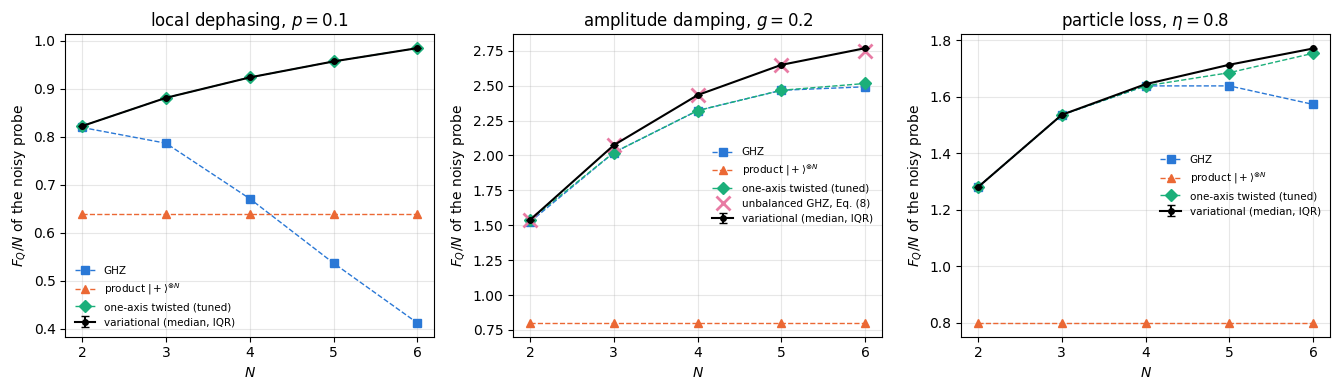


amplitude damping: variational optimum vs the best unbalanced GHZ state, Eq. (8)
  N=2: F_opt - F_uGHZ = +2.22e-15  (spread of the top 4 starts 1.8e-15)   |a_0..0|^2 = 0.4519  s* = 0.4519   GHZ overlap 0.9977
  N=3: F_opt - F_uGHZ = +3.55e-15  (spread of the top 4 starts 1.3e-07)   |a_0..0|^2 = 0.4190  s* = 0.4190   GHZ overlap 0.9934
  N=4: F_opt - F_uGHZ = -1.40e-08  (spread of the top 4 starts 8.3e-06)   |a_0..0|^2 = 0.3907  s* = 0.3907   GHZ overlap 0.9879
  N=5: F_opt - F_uGHZ = -5.47e-08  (spread of the top 4 starts 3.7e-05)   |a_0..0|^2 = 0.3642  s* = 0.3642   GHZ overlap 0.9812
  N=6: F_opt - F_uGHZ = +1.08e-01  (spread of the top 4 starts 1.1e-03)   |a_0..0|^2 = 0.3128  s* = 0.3387   GHZ overlap 0.8994


In [13]:
# ==============================================================================
# STEP 8: F_Q against N, gains over the best baseline, and the unbalanced-GHZ hypothesis under damping
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0))
titles = {"dephasing": f"local dephasing, $p={P_DEPH}$", "damping": f"amplitude damping, $g={G_DAMP}$",
          "loss": rf"particle loss, $\eta={ETA}$"}
print(f"{'channel':>9s} {'N':>2s} | {'F_opt':>8s} {'IQR over starts':>19s} | {'best baseline':>13s} {'which':>5s} | "
      f"{'F_opt - baseline':>16s} {'ratio':>7s}")
for ax, ch in zip(axes, CHANNELS):
    Ns = np.array(N_LIST)
    q25, q50, q75 = (np.array([np.percentile(noisy[(ch, N)]["final"], q) for N in N_LIST]) / Ns for q in (25, 50, 75))
    for key, lab, mk in [("ghz", "GHZ", "s"), ("prod", r"product $\vert+\rangle^{\otimes N}$", "^"),
                         ("oat", "one-axis twisted (tuned)", "D")]:
        ax.plot(Ns, [baseline[(ch, N)][key] / N for N in N_LIST], marker=mk, ls="--", lw=1, label=lab)
    if ch == "damping":
        ax.plot(Ns, [best_unbalanced_ghz_damping(N, G_DAMP)[1] / N for N in N_LIST], "x", ms=10, mew=2,
                color=PALETTE[4], label="unbalanced GHZ, Eq. (8)")
    ax.errorbar(Ns, q50, yerr=[q50 - q25, q75 - q50], fmt="o-", color="k", ms=4, capsize=3,
                label="variational (median, IQR)")
    ax.set_xlabel("$N$")
    ax.set_ylabel(r"$F_Q/N$ of the noisy probe")
    ax.set_title(titles[ch])
    ax.legend(fontsize=7.5)
    for N in N_LIST:
        f = noisy[(ch, N)]["final"]
        b = {k: baseline[(ch, N)][k] for k in ("ghz", "prod", "oat")}
        kbest = max(b, key=b.get)
        print(f"{ch:>9s} {N:2d} | {f.max():8.4f} [{np.percentile(f, 25):8.4f},{np.percentile(f, 75):8.4f}] | "
              f"{b[kbest]:13.4f} {kbest:>5s} | {f.max() - b[kbest]:+16.1e} {f.max() / b[kbest]:7.4f}")
plt.tight_layout()
plt.show()

# amplitude damping: the variational optimum against the unbalanced GHZ state of Eq. (8)
print("\namplitude damping: variational optimum vs the best unbalanced GHZ state, Eq. (8)")
for N in N_LIST:
    s_star, f_star = best_unbalanced_ghz_damping(N, G_DAMP)
    f = noisy[("damping", N)]["final"]
    pop0 = float(jnp.abs(noisy[("damping", N)]["psi"].reshape(-1)[0]) ** 2)
    print(f"  N={N}: F_opt - F_uGHZ = {f.max() - f_star:+.2e}  (spread of the top 4 starts {np.ptp(np.sort(f)[-4:]):.1e})"
          f"   |a_0..0|^2 = {pop0:.4f}  s* = {s_star:.4f}   GHZ overlap {ghz_overlap(noisy[('damping', N)]['psi']):.4f}")

The figure shows $F_Q/N$, in which the standard quantum limit of an ideal probe is the constant 1 and the Heisenberg
limit grows like $N$; the bars are the interquartile range (IQR) over the 8 starts, mostly smaller than the markers.
The table lists the best variational value, the IQR, the best baseline and the difference.

* **Dephasing.** The variational probe and the tuned twisted probe agree: the differences are below $10^{-5}$ for
  $N\le5$, and at $N=6$ the twisted probe is ahead by $1.6\times10^{-4}$, within the drift of the unfinished $N=6$ runs.
  Both beat the GHZ state at every $N$ (by $0.35\%$ at $N=2$ and by a factor 2.39 at $N=6$) and the product state at
  every $N$ (by a factor 1.54 at $N=6$). Within this data, nothing beyond the twisted family is gained.
* **Damping.** From $N=3$ the variational probe beats the GHZ, product and tuned twisted probes, by $2.6\%$, $4.8\%$,
  $7.4\%$ and $10.1\%$ for $N=3,4,5,6$; each gain exceeds the IQR over starts by a factor of 100 or more. At $N=2$ it
  equals the tuned twisted probe. These three families do not contain the unbalanced GHZ state of Eq. (8), the crosses
  in the middle panel, which is the stronger competitor and is examined in the second part of the cell.
* **Loss.** At $N=2,3$ the GHZ state is optimal within numerical accuracy. From $N=4$ the variational probe is ahead,
  by $0.4\%$, $1.7\%$ and $1.1\%$, small gains but 7–30 times the IQR; these values are lower bounds (Section 6.2).

The second part of the cell tests the hypothesis suggested by Section 3.5, that under damping the optimum is the
unbalanced GHZ state of Eq. (8). For $N\le5$ it passes: the variational value equals $F^\ast$ to $6\times10^{-8}$ and the
population of $\vert0\cdots0\rangle$ equals $s^\ast$ to four digits, so the whole gain over the three families comes from
unbalancing the GHZ state. At $N=6$ the hypothesis fails: the variational value exceeds $F^\ast$ by $0.108$ ($0.7\%$), a
hundred times the spread of the four best starts, and the state has only $0.90$ overlap with the closest GHZ state.
Koczor *et al.* (2020) report a similar observation, ansatz states for amplitude damping that are not permutation
symmetric from $N=5$ on and beat GHZ and all symmetric states, in a setting where the sensing time is optimised as
well; they explain the advantage by a passive correction of single decay events.

### 6.4 The circuit optimum against an optimum over all states

The circuit restricts the probes that can be reached, and at $N=6$ the runs had not finished. For $N\le6$ the state
space is small enough to drop the circuit altogether: a real vector $\mathbf v$ of length $2^{N+1}$ defines the probe
$\psi=(\mathbf v_{\rm re}+i\mathbf v_{\rm im})/\Vert\mathbf v\Vert$, and the same cost, Eq. (2) or Eq. (3), is maximised
over $\mathbf v$ with the same `qfi_dm` gradient and Adam (step size $0.05$, 1000 steps, 4 starts). Every normalised
state is reachable, so the result is the best value over all probes, up to the usual caveat of a local optimiser. This
is the problem that the alternating algorithm of Macieszczak (2013) solves; the circuit is what a device can prepare.

In [14]:
# ==============================================================================
# STEP 8b: the same optimisation over all normalised states (no circuit), N = 4, 5, 6
# ==============================================================================
def free_probe(v, N):
    """Unrestricted probe: v (real, length 2^(N+1)) -> psi = (v[:2^N] + i v[2^N:]) / ||.||, shape (2,)*N.

    JAX   the normalisation is differentiable, so `jax.grad` of any cost of psi gives the gradient on the sphere
          (the radial component of the gradient vanishes because the cost does not depend on ||v||).
    """
    d = 2 ** N
    psi = (v[:d] + 1j * v[d:]).astype(CDTYPE)
    return (psi / jnp.linalg.norm(psi)).reshape((2,) * N)


R_FREE, STEPS_FREE, LR_FREE = 4, 1000, 0.05
free = {}
print(f"{'channel':>9s} {'N':>2s} | {'circuit (Step 7)':>16s} {'all states':>10s} {'difference':>10s} | "
      f"{'spread of starts':>16s} {'last-100 change':>15s}")
for N in [4, 5, 6]:
    v0 = jax.random.normal(jax.random.PRNGKey(2000 + N), (R_FREE, 2 ** (N + 1)), dtype=RDTYPE)
    tables = loss_tables(N)
    costs = {"dm": lambda v, a, N=N: qfi_after_channel(free_probe(v, N), a),
             "loss": lambda v, a, N=N, t=tables: qfi_after_loss(free_probe(v, N), a, t)}
    fns = {fam: jax.jit(jax.vmap(lambda v, a, c=c: ascend(lambda w: c(w, a), v, LR_FREE, STEPS_FREE), in_axes=(0, None)))
           for fam, c in costs.items()}
    for ch in CHANNELS:
        _, hist = fns["loss" if ch == "loss" else "dm"](v0, noise_arg(ch))
        hist = np.asarray(hist)
        free[(ch, N)] = hist[:, -1].max()
        f_circ = noisy[(ch, N)]["final"].max()
        print(f"{ch:>9s} {N:2d} | {f_circ:16.6f} {free[(ch, N)]:10.6f} {free[(ch, N)] - f_circ:10.1e} | "
              f"{np.ptp(hist[:, -1]):16.1e} {np.max(np.abs(hist[:, -1] - hist[:, -101])):15.1e}")
for N in [4, 5]:
    assert abs(free[("damping", N)] - best_unbalanced_ghz_damping(N, G_DAMP)[1]) < 1e-6     # Eq. (8) over all states
for key in free:
    assert free[key] >= noisy[key]["final"].max() - 1e-6                                     # no circuit beats all states

  channel  N | circuit (Step 7) all states difference | spread of starts last-100 change


dephasing  4 |         3.693135   3.693135   -8.9e-16 |          9.8e-15         1.1e-14


  damping  4 |         9.731753   9.731753    1.4e-08 |          3.9e-14         1.8e-14


     loss  4 |         6.577734   6.578145    4.1e-04 |          1.4e-05         3.8e-06


dephasing  5 |         4.783113   4.783113    3.9e-10 |          1.2e-14         1.2e-14


  damping  5 |        13.248023  13.248023    5.5e-08 |          2.7e-14         3.9e-14


     loss  5 |         8.571639   8.580587    8.9e-03 |          4.1e-08         4.8e-08


dephasing  6 |         5.906198   5.906388    1.9e-04 |          1.2e-14         8.9e-15


  damping  6 |        16.619085  16.619778    6.9e-04 |          7.5e-03         1.1e-12


     loss  6 |        10.637691  10.665423    2.8e-02 |          5.0e-06         1.3e-05


For dephasing and damping at $N=4,5$ the circuit reaches the optimum over all states to $6\times10^{-8}$, so the
hardware-efficient ansatz with $L=N$ is no restriction there, and Eq. (8) is the best probe over all states for
$N\le5$, not only within the circuit. At $N=6$ the circuit falls short by $1.9\times10^{-4}$ (dephasing) and
$6.9\times10^{-4}$ (damping), as expected from the unfinished runs. The dephasing value over all states, $5.906388$,
agrees with the tuned twisted state ($5.9064$) to the four printed decimals: at these sizes the one-axis-twisted
family contains the optimal dephasing probe. Under loss the gaps are larger, $4\times10^{-4}$, $9\times10^{-3}$ and
$2.8\times10^{-2}$ for $N=4,5,6$, and with the values over all states the gains over the best baseline become
$0.37\%$, $1.8\%$ and $1.4\%$. One of the four damping starts at $N=6$ stopped $7.5\times10^{-3}$ below the others, so
local optima exist without a circuit too. The unrestricted search is a classical design tool for small $N$; a device
has to prepare the probe with a circuit, which is why the circuit optimum is the quantity of interest.

## 7. What the optimal states look like

Section 5 showed that the angles of an optimum are meaningless, so we characterise the optimal states by numbers that
do not change under the symmetries of the problem. Besides the collective rotation $e^{-iaJ_z}$, the cost is invariant
under an independent rotation $R_z(\alpha_q)$ of every qubit: each one commutes with $J_z$, with the dephasing and
damping channels (Section 3.2), and with the partial traces of Eq. (3). Two probes that differ by
$\bigotimes_qR_z(\alpha_q)$ are therefore equally good, although their overlap can be small. For the best start at $N=6$
the next cell computes

* the **excitation distribution** $P(k)$, the probability of finding $k$ qubits in $\vert1\rangle$, which is the
  distribution of $J_z=N/2-k$ and determines the noiseless QFI through $4\,\mathrm{Var}(J_z)$;
* the **symmetric weight** $\max_{\boldsymbol\alpha}\sum_k\vert\langle D_N^k\vert\bigotimes_qR_z(\alpha_q)\vert\psi\rangle\vert^2$,
  the weight in the permutation-symmetric subspace spanned by the Dicke states $\vert D_N^k\rangle$ (equal
  superpositions of all strings with $k$ ones), maximised over the local rotations; it is 1 for GHZ, product and
  twisted probes;
* the **half-chain entanglement entropy** $S(3\vert3)=-\mathrm{Tr}\rho_A\log_2\rho_A$ of the first three qubits, of
  the optimum and of the tuned twisted state (local rotations do not change it);
* the **GHZ overlap** $\max_\chi\vert\langle{\rm GHZ}_\chi\vert\psi\rangle\vert^2$, which depends only on
  $\vert\psi_{0\cdots0}\vert$ and $\vert\psi_{1\cdots1}\vert$ and so is invariant as well;
* the **overlap with the tuned twisted probe**, $\max_{\boldsymbol\alpha}\vert\langle\psi_{\rm OAT}\vert\bigotimes_qR_z(\alpha_q)\vert\psi\rangle\vert^2$.

Both maximisations over $\boldsymbol\alpha\in[-\pi,\pi]^N$ use Adam from 16 random starts.

  channel |                            P(k), k = 0..6 | sym. weight  S(3|3)  S_OAT  GHZ ovl  OAT ovl max|P - P_OAT|


dephasing | 0.176 0.119 0.137 0.135 0.139 0.117 0.177 |      0.5465  1.7019 0.6650   0.3530   0.3237         0.0039


  damping | 0.313 0.000 0.070 0.000 0.005 0.000 0.611 |      0.9395  1.1373 1.2051   0.8994   0.8769         0.1570


     loss | 0.330 0.051 0.092 0.053 0.096 0.050 0.328 |      0.9559  0.9465 1.2402   0.6578   0.8993         0.0675


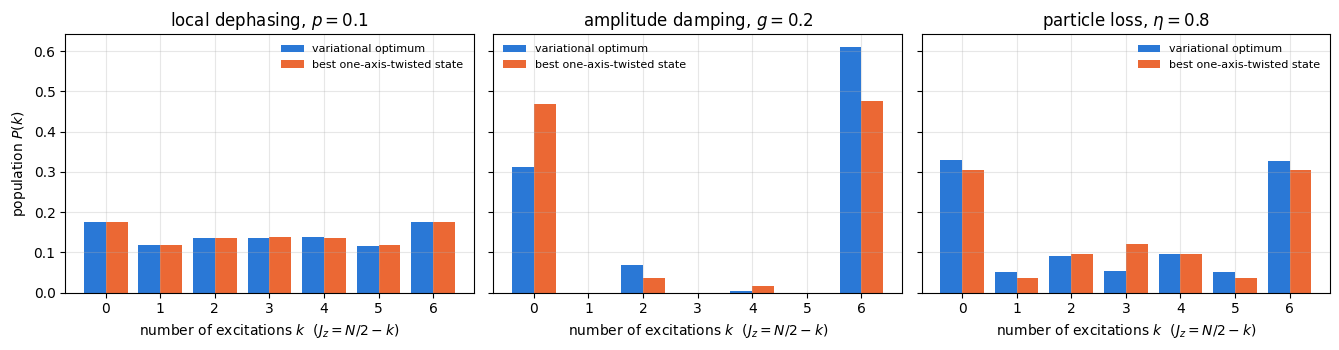

loss optimum, Eq. (3) split: all particles survive 6.8305, some lost 3.8072, total 10.6377 (GHZ: 9.4372 + 0)


In [15]:
# ==============================================================================
# STEP 9: anatomy of the optimised probes at N = 6
# ==============================================================================
def hamming_populations(psi):
    """P(k) = probability of k excitations (qubits in |1>), i.e. of J_z = N/2 - k:  sum over |x| = k of |psi_x|^2."""
    N = psi.ndim
    w = np.array([bin(i).count("1") for i in range(2 ** N)])
    p = np.abs(np.asarray(psi).reshape(-1)) ** 2
    return np.bincount(w, weights=p, minlength=N + 1)


def local_z_rotate(psi_flat, alpha, mq):
    """(prod_q R_z(alpha_q)) psi in the computational basis:  psi_x -> exp(-i sum_q alpha_q m_q(x)) psi_x,
    with m_q(x) = +-1/2 the J_z value of qubit q in the string x (`mq`, shape (2^N, N))."""
    return psi_flat * jnp.exp(-1j * (mq @ alpha))


def max_over_local_z(fun, N, n_starts=16, steps=300, seed=0):
    """max over alpha in R^N of fun(alpha) (a scalar of the locally rotated state), by Adam from n_starts random alphas."""
    a0 = random_starts(n_starts, N, seed)
    _, hist = jax.jit(jax.vmap(lambda a: ascend(fun, a, 0.05, steps)))(a0)
    return float(jnp.max(hist[:, -1]))


def symmetric_weight_local_z(psi):
    """max over local z rotations of sum_k |<D_N^k| R(alpha) psi>|^2  (Dicke states D_N^k)."""
    N = psi.ndim
    mq = jnp.asarray(0.5 - ((np.arange(2 ** N)[:, None] >> np.arange(N - 1, -1, -1)[None, :]) & 1), dtype=RDTYPE)
    D = jnp.stack([dicke_state(N, k).reshape(-1) for k in range(N + 1)])
    f = psi.reshape(-1)
    return max_over_local_z(lambda a: jnp.sum(jnp.abs(D.conj() @ local_z_rotate(f, a, mq)) ** 2), N)


def overlap_local_z(psi, phi):
    """max over local z rotations of |<phi| R(alpha) |psi>|^2."""
    N = psi.ndim
    mq = jnp.asarray(0.5 - ((np.arange(2 ** N)[:, None] >> np.arange(N - 1, -1, -1)[None, :]) & 1), dtype=RDTYPE)
    f, g = psi.reshape(-1), phi.reshape(-1)
    return max_over_local_z(lambda a: jnp.abs(jnp.vdot(g, local_z_rotate(f, a, mq))) ** 2, N)


N = 6
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6), sharey=True)
print(f"{'channel':>9s} | {'P(k), k = 0..6':>41s} | {'sym. weight':>11s} {'S(3|3)':>7s} {'S_OAT':>6s} {'GHZ ovl':>8s} "
      f"{'OAT ovl':>8s} {'max|P - P_OAT|':>14s}")
for ax, ch in zip(axes, CHANNELS):
    psi = noisy[(ch, N)]["psi"]
    P = hamming_populations(psi)
    oat_psi = oat_probe(jnp.asarray(baseline[(ch, N)]["oat_params"]), N)
    S_half = float(entanglement_entropy(psi, list(range(N // 2))))
    S_oat = float(entanglement_entropy(oat_psi, list(range(N // 2))))
    print(f"{ch:>9s} | " + " ".join(f"{x:5.3f}" for x in P) + f" | {symmetric_weight_local_z(psi):11.4f} {S_half:7.4f} "
          f"{S_oat:6.4f} {ghz_overlap(psi):8.4f} {overlap_local_z(psi, oat_psi):8.4f} "
          f"{np.max(np.abs(P - hamming_populations(oat_psi))):14.4f}")
    ax.bar(np.arange(N + 1) - 0.2, P, width=0.4, label="variational optimum")
    ax.bar(np.arange(N + 1) + 0.2, hamming_populations(oat_psi), width=0.4, label="best one-axis-twisted state")
    ax.set_xlabel("number of excitations $k$  ($J_z=N/2-k$)")
    ax.set_title(titles[ch])
    ax.legend(fontsize=8)
axes[0].set_ylabel("population $P(k)$")
plt.tight_layout()
plt.show()

psi_loss = noisy[("loss", N)]["psi"]
f_all = ETA ** N * float(qfi_pure(psi_loss))
f_tot = float(probe_cost("loss", N)(psi_loss))
print(f"loss optimum, Eq. (3) split: all particles survive {f_all:.4f}, some lost {f_tot - f_all:.4f}, total {f_tot:.4f} "
      f"(GHZ: {f_ghz_loss(N, ETA):.4f} + 0)")

The three optimal probes are of different kinds.

* **Dephasing.** $P(k)$ is spread over all $k$ ($0.12$–$0.18$) and agrees with that of the tuned twisted state to
  $0.004$ (left panel), yet even after the best local rotations the state has only $0.55$ of its weight in the symmetric
  subspace and an overlap of $0.32$ with the twisted state. Its half-chain entropy, $S=1.70$ of a possible 3, differs
  from the $0.67$ of the twisted state. Local rotations do not change an entropy, and a permutation of the qubits maps
  the twisted state to itself, so the two states are not related by a symmetry of the problem. Their values of $F$ are nevertheless equal. The optimum under dephasing is therefore
  degenerate beyond the symmetries: the circuit found a non-symmetric state outside the twisted family, all of whose
  members are symmetric.
* **Damping.** $P(k)$ is non-zero only for even $k$ ($0.313$, $0.070$, $0.005$, $0.611$ for $k=0,2,4,6$), the weight
  sits mostly on the two GHZ components with more on $\vert1\cdots1\rangle$, as in Eq. (8), and the state is nearly
  symmetric ($0.94$) with GHZ overlap $0.90$. The extra weight at $k=2$ ($7\%$) and $k=4$ ($0.5\%$) is what distinguishes
  it from the unbalanced GHZ state of Eq. (8), which it beats by $0.108$.
* **Loss.** The weights at $k=0$ and $k=6$ are equal ($0.33$), the remaining third is spread over the other $k$ with
  more on even $k$, and the GHZ overlap is $0.66$. Up to local rotations the state is nearly symmetric ($0.96$) and has
  overlap $0.90$ with the tuned twisted state, which it beats by $1.1\%$. The last line of the output splits Eq. (3) for
  this state: the all-survive term is smaller than the $\eta^NN^2=9.44$ of a GHZ state, and the terms in which particles
  were lost, zero for GHZ (Eq. 5c), make up the difference and more.

The even-$k$ structure under damping is not analysed here; the data establish only that the best of the 8 starts has
it. Koczor *et al.* (2020) relate the non-symmetric optimal states under damping to a passive correction of single
decay events, and Exercise 7 asks how much of the gain survives a restriction to symmetric states.

## 8. The measurement: classical Fisher information of a readout circuit

The QFI bounds the precision of the best possible measurement. An experiment measures something specific, here each
qubit in the computational basis after a readout circuit $V(\boldsymbol\phi)$, and the relevant number is the
**classical Fisher information** (CFI) of the measured bit strings $x$,

$$F_C(\theta)=\sum_x\frac{\big(\partial_\theta p_x(\theta)\big)^2}{p_x(\theta)},\qquad p_x(\theta)=\langle x\vert V\rho_\theta V^\dagger\vert x\rangle. \tag{14}$$

Braunstein and Caves (1994) showed $F_C\le F_Q$ for every measurement, with equality for the projective measurement in
the eigenbasis of the SLD (proved in notebook 29, Section 5.3, and constructed in notebook 30, Section 8). Every
projective measurement is a computational-basis measurement after some unitary $V$; the question is how deep $V$ must be.

**From formula to code.** By linearity, $\partial_\theta p_x=\langle x\vert V(\partial_\theta\rho_\theta)V^\dagger\vert x\rangle$
with $\partial_\theta\rho_\theta=-i[J_z,\rho_\theta]$, so `outcome_probs_and_derivs` pushes $\rho$ and
$\partial_\theta\rho$ through the same readout circuit and reads off the diagonals. The readout circuit is the
hardware-efficient layer structure, with rotations $R_yR_z$ (first $R_z$, then $R_y$) on every qubit at the end: depth $L=0$ is a layer of independent
single-qubit rotations, that is, a local measurement of each qubit along its own axis; $L\ge1$ adds entangling CZ
layers. We optimise at $\theta=0$. This is not a restriction: a working point $\theta_0$ is a collective rotation
$e^{-i\theta_0J_z}=\bigotimes R_z(\theta_0)$, which the first rotation layer absorbs. The optimised readout is, however,
tuned to one working point, which Step 12 examines.

We compare with three fixed readouts that rotate every qubit by the same $R_y(b)R_z(a)$ (tuned over a $96\times49$ grid
of $(a,b)$) and then

* record the **parity** $(-1)^{\vert x\vert}$, the GHZ readout of notebook 32;
* record the **number of ones** $\vert x\vert$, spin counting, i.e. a measurement of the collective spin along the
  rotated axis, the readout of Ramsey and squeezing experiments (notebooks 31, 33);
* record the full bit string.

Parity and counting are functions of the bit string, and coarse graining cannot increase the CFI: for a group $c$ of
outcomes, Cauchy–Schwarz gives $\big(\sum_{x\in c}\partial p_x\big)^2\le\sum_{x\in c}p_x\cdot\sum_{x\in c}(\partial p_x)^2/p_x$.
So parity and counting give at most the bit-string value, and the bit-string readout with a common rotation is itself a special case of
$L=0$. We use $N=4$ and the variational probes of Section 6 for dephasing and damping, and the GHZ state under damping as
a reference.

The checkpoint confirms the two ends of the range: the SLD eigenbasis must give $F_C=F_Q$, and the bare computational
basis must give $F_C=0$, because $J_z$ is diagonal and the populations $p_x=\langle x\vert\rho_\theta\vert x\rangle$ do
not depend on $\theta$.

In [16]:
# ==============================================================================
# STEP 10: classical Fisher information of a readout circuit followed by a computational-basis measurement
# ==============================================================================
def readout_dm(rho, phi, L):
    """Readout circuit V(phi) on a density tensor:  [R]  then L times [CZ chain, R],   R = prod_q R_y R_z.

    `phi` has shape ((L+1) * N * 2,).  L = 0 is a layer of independent single-qubit rotations: a local measurement.
    """
    N = rho.ndim // 2
    phi = phi.reshape(L + 1, N, 2)
    for l in range(L + 1):
        if l > 0:
            for q in range(N - 1):
                rho = apply_gate_dm(rho, CZ, [q, q + 1])
        for q in range(N):
            rho = apply_gate_dm(rho, rz(phi[l, q, 0]), [q])
            rho = apply_gate_dm(rho, ry(phi[l, q, 1]), [q])
    return rho


def outcome_probs_and_derivs(rho, phi, L):
    """p_x and d p_x / d theta at theta = 0 for the readout V(phi) and the bit string x.

    MATH   p_x = <x| V rho V^dagger |x>,    d p_x = <x| V (-i[J_z, rho]) V^dagger |x>     (linearity of the readout)
    """
    m = jz_diagonal(rho.ndim // 2)
    rm = dm_matrix(rho)
    drho = (-1j * (m[:, None] - m[None, :]) * rm).reshape(rho.shape)
    p = jnp.real(jnp.diagonal(dm_matrix(readout_dm(rho, phi, L))))
    dp = jnp.real(jnp.diagonal(dm_matrix(readout_dm(drho, phi, L))))
    return p, dp


def classical_fisher(p, dp, tol=1e-12):
    """F_C = sum_x (d p_x)^2 / p_x, outcomes with p_x = 0 masked by a double jnp.where (they contribute 0)."""
    ok = p > tol
    return jnp.sum(jnp.where(ok, dp ** 2 / jnp.where(ok, p, 1.0), 0.0))


def coarse_grain(p, labels, n_labels):
    """Probabilities of a coarse-grained outcome (parity, number of ones) from the bit-string distribution."""
    return jax.ops.segment_sum(p, labels, num_segments=n_labels)


N_M = 4
ones = jnp.asarray([bin(i).count("1") for i in range(2 ** N_M)])
probes_M = {"dephasing": (noisy[("dephasing", N_M)]["psi"], KRAUS["dephasing"]),
            "damping": (noisy[("damping", N_M)]["psi"], KRAUS["damping"]),
            "GHZ, damping": (ghz_state(N_M), KRAUS["damping"])}

# --- CHECKPOINT 3: the SLD eigenbasis saturates F_Q; the computational basis carries nothing ---------------
for name, (psi, kraus) in probes_M.items():
    rho = channel_on_all(to_dm(psi), kraus)
    F_Q, Lsld = qfi_and_sld(dm_matrix(rho), jz_diagonal(N_M))
    _, W = jnp.linalg.eigh(Lsld)                                  # columns: eigenvectors of the SLD
    rm = dm_matrix(rho)
    m = jz_diagonal(N_M)
    drho = -1j * (m[:, None] - m[None, :]) * rm
    p_sld = jnp.real(jnp.einsum("ax,ab,bx->x", W.conj(), rm, W))
    dp_sld = jnp.real(jnp.einsum("ax,ab,bx->x", W.conj(), drho, W))
    F_sld = float(classical_fisher(p_sld, dp_sld))
    F_z = float(classical_fisher(jnp.real(jnp.diagonal(rm)), jnp.real(jnp.diagonal(drho))))
    print(f"{name:>13s}: F_Q = {float(F_Q):.6f}   F_C(SLD eigenbasis) = {F_sld:.6f}   F_C(computational basis) = {F_z:.1e}")
    assert abs(F_sld - float(F_Q)) < 1e-8 and F_z < 1e3 * TOL

    dephasing: F_Q = 3.693135   F_C(SLD eigenbasis) = 3.693135   F_C(computational basis) = 0.0e+00
      damping: F_Q = 9.731753   F_C(SLD eigenbasis) = 9.731753   F_C(computational basis) = 0.0e+00
 GHZ, damping: F_Q = 9.287982   F_C(SLD eigenbasis) = 9.287982   F_C(computational basis) = 0.0e+00


The SLD eigenbasis reproduces $F_Q$ to the printed six digits for all three probes, and the computational basis gives
exactly zero. A readout circuit is necessary, and an optimal one exists.

In [17]:
# ==============================================================================
# STEP 11: parity, spin counting, and optimised readout circuits of depth L = 0..3
# ==============================================================================
def fc_common_rotation(rho, a, b, kind):
    """F_C after the same rotation R_y(b) R_z(a) on every qubit, read out as parity, as number of ones, or as bit strings.

    The z rotation by a includes the choice of working point: e^{-i theta0 J_z} is a collective R_z(theta0).
    """
    N = rho.ndim // 2
    phi = jnp.tile(jnp.array([a, b]), N)
    p, dp = outcome_probs_and_derivs(rho, phi, 0)
    if kind == "parity":
        p, dp = coarse_grain(p, ones % 2, 2), coarse_grain(dp, ones % 2, 2)
    elif kind == "counting":
        p, dp = coarse_grain(p, ones, N + 1), coarse_grain(dp, ones, N + 1)
    return classical_fisher(p, dp)


ab = jnp.stack(jnp.meshgrid(jnp.linspace(0, 2 * np.pi, 96, endpoint=False), jnp.linspace(0, np.pi, 49), indexing="ij"),
               -1).reshape(-1, 2)
L_READ = [0, 1, 2, 3]
R_READ, STEPS_READ = 8, 400
# one compiled program per readout kind / depth; the noisy state rho and the step size are traced arguments
coarse_fn = {kind: jax.jit(jax.vmap(lambda x, r, k=kind: fc_common_rotation(r, x[0], x[1], k), in_axes=(0, None)))
             for kind in ["parity", "counting", "bits"]}
read_cost = lambda ph, r, L: classical_fisher(*outcome_probs_and_derivs(r, ph, L))
read_train = {L: jax.jit(jax.vmap(lambda p, r, lr, L=L: ascend(lambda q: read_cost(q, r, L), p, lr, STEPS_READ),
                                  in_axes=(0, None, None))) for L in L_READ}

# step-size bracket for the readout optimisation: damping probe, L = 2; the best median is used below
rho_b = channel_on_all(to_dm(probes_M["damping"][0]), probes_M["damping"][1])
ph0 = random_starts(R_READ, 2 * N_M * 3, seed=390)            # starts not reused below
bracket = {lr: float(np.median(np.asarray(read_train[2](ph0, rho_b, lr)[1])[:, -1]))
           for lr in [0.1, 0.2, 0.4, 0.8, 1.6]}
LR_READ = max(bracket, key=bracket.get)
print("readout step-size bracket (damping probe, L = 2), median F_C over 8 starts: "
      + ", ".join(f"lr={lr}: {v:.4f}" for lr, v in bracket.items()) + f"  ->  LR_READ = {LR_READ}")

readout = {}
for name, (psi, kraus) in probes_M.items():
    rho = channel_on_all(to_dm(psi), kraus)
    row = {"F_Q": float(qfi_and_sld(dm_matrix(rho), jz_diagonal(N_M))[0])}
    for kind in ["parity", "counting", "bits"]:
        row[kind] = float(jnp.max(coarse_fn[kind](ab, rho)))
    for L in L_READ:
        ph0 = random_starts(R_READ, 2 * N_M * (L + 1), seed=300 + L)
        ph, hist = read_train[L](ph0, rho, LR_READ)
        final = np.asarray(hist)[:, -1]
        row[f"L{L}"] = final
        row[f"phi{L}"] = ph[int(np.argmax(final))]
    readout[name] = row
print(f"{'probe':>13s} {'F_Q':>7s} | {'parity':>7s} {'count':>7s} {'bits':>7s} | "
      + " ".join(f"{'L=' + str(L) + ' best (median)':>21s}" for L in L_READ))
for name, r in readout.items():
    print(f"{name:>13s} {r['F_Q']:7.4f} | {r['parity']:7.4f} {r['counting']:7.4f} {r['bits']:7.4f} | "
          + " ".join(f"{r[f'L{L}'].max():10.4f} ({np.median(r[f'L{L}']):7.4f})  " for L in L_READ))
    assert max(r[f"L{L}"].max() for L in L_READ) <= r["F_Q"] + 1e-8      # Braunstein-Caves: F_C <= F_Q

readout step-size bracket (damping probe, L = 2), median F_C over 8 starts: lr=0.1: 9.2803, lr=0.2: 9.2803, lr=0.4: 9.2803, lr=0.8: 9.5059, lr=1.6: 9.2803  ->  LR_READ = 0.8


        probe     F_Q |  parity   count    bits |     L=0 best (median)     L=1 best (median)     L=2 best (median)     L=3 best (median)
    dephasing  3.6931 |  1.1986  1.2461  1.2976 |     2.0926 ( 2.0926)       2.8402 ( 2.8074)       3.2632 ( 3.1651)       3.3797 ( 3.2974)  
      damping  9.7318 |  6.2126  6.2126  6.2126 |     6.2405 ( 6.2405)       9.2803 ( 9.0501)       9.7318 ( 9.7290)       9.7318 ( 9.2803)  
 GHZ, damping  9.2880 |  6.5536  6.5536  6.5536 |     6.5536 ( 6.5536)       8.9628 ( 8.0891)       9.2880 ( 8.9628)       9.2880 ( 9.2880)  


The step-size bracket first, on starts that are not reused in the table: the median over 8 starts is $9.28$ for every
initial step except $\alpha_0=0.8$, where it is $9.51$, and this value is used. The value $9.28$ is the best
one-layer readout of the table, a local optimum of the two-layer landscape. The readout landscape rewards larger steps than the probe landscape
of Section 6, where $\alpha_0=0.1$ sufficed. The table gives $F_C$ for every readout:

* **Fixed readouts.** For the dephasing probe, parity, counting and full bit strings after a common rotation give
  $1.20$, $1.25$ and $1.30$, about a third of $F_Q=3.69$. Independent local rotations ($L=0$) reach $2.09$
  ($57\%$). For the two damping probes the three common-rotation readouts coincide ($6.21$ and $6.55$); for the GHZ state
  under damping $6.55=N^2(1-g)^N$ is the parity result of notebook 32, $N^2C^2$ with contrast $C=(1-g)^{N/2}$, and
  local rotations do not improve on it.
* **Entangling readouts.** One CZ layer lifts the damping probe from $6.24$ to $9.28$, and with $L=2$ the best start
  reaches $F_Q$ to the printed four digits, for the variational probe and for GHZ alike. The dephasing probe needs more:
  $L=1,2,3$ give $2.84$, $3.26$ and $3.38$, so three layers recover $92\%$ of $F_Q$ and leave a gap of $0.31$.
* **Starts matter.** The medians can lie well below the best values (variational damping probe at $L=3$: median
  $9.28$ against $9.73$; GHZ at $L=1$: $8.09$ against $8.96$): the readout landscape has local optima, and several
  starts are needed.

So the gap $F_Q-F_C$ of a local measurement is large for these probes ($36$–$43\%$ of $F_Q$ for the variational ones),
an entangling readout circuit closes it, and how deep that circuit must be depends on the probe: two layers for the
nearly GHZ-like damping probe, while three layers are not enough for the dephasing probe, whose excitation
distribution is spread over all $k$.

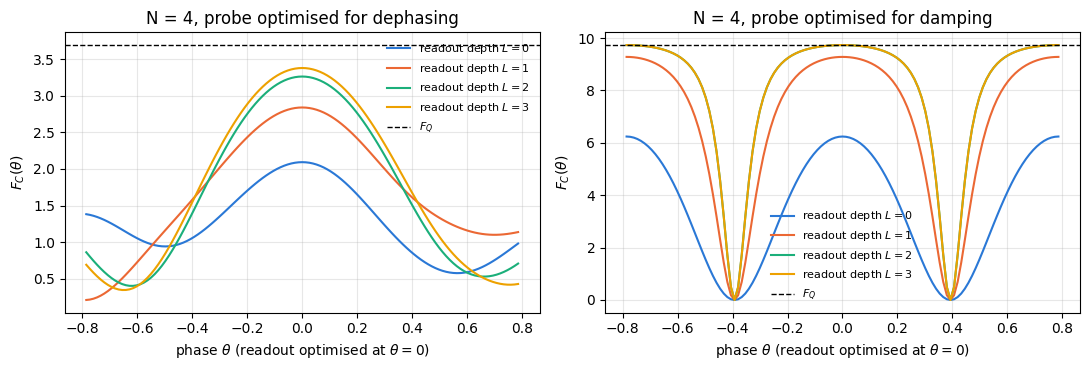

In [18]:
# ==============================================================================
# STEP 12: the readout is optimised at one working point -- F_C(theta) around it
# ==============================================================================
def fc_at_theta(rho, phi, L, theta):
    """F_C of the readout V(phi) when the true phase is theta (state rotated by e^{-i theta J_z} before the readout)."""
    N = rho.ndim // 2
    for q in range(N):
        rho = apply_gate_dm(rho, rz(theta), [q])
    return classical_fisher(*outcome_probs_and_derivs(rho, phi, L))


thetas = jnp.linspace(-np.pi / N_M, np.pi / N_M, 121)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=False)
for ax, name in zip(axes, ["dephasing", "damping"]):
    psi, kraus = probes_M[name]
    rho = channel_on_all(to_dm(psi), kraus)
    for L in L_READ:
        curve = jax.jit(jax.vmap(lambda t, L=L: fc_at_theta(rho, readout[name][f"phi{L}"], L, t)))(thetas)
        ax.plot(thetas, curve, label=f"readout depth $L={L}$")
    ax.axhline(readout[name]["F_Q"], color="k", ls="--", lw=1, label=r"$F_Q$")
    ax.set_xlabel(r"phase $\theta$ (readout optimised at $\theta=0$)")
    ax.set_ylabel(r"$F_C(\theta)$")
    ax.set_title(f"N = {N_M}, probe optimised for {name}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Each readout was optimised at $\theta=0$, and the curves show that it is good only near that point. For the damping
probe every readout, including $L=0$, has zeros at $\theta=\pm\pi/(2N)=\pm0.39$, where the signal of the $N$-body coherence
is at an extremum and its derivative vanishes, as for the parity fringe of notebook 32; the pattern repeats with period
$\pi/N$. The dephasing probe gives broader curves, with the maximum at $\theta=0$ and a fall to $0.2$–$1.4$ at
$\vert\theta\vert\approx0.6$–$0.8$. In practice the phase must be known in advance to within a fraction of $\pi/N$, or the
readout must be adapted as the estimate improves; the QFI, independent of $\theta$ for a unitary orbit (Section 3.2),
hides this requirement.

## 9. Practical lessons

### 9.1 Cost

The training programs of Step 7 were compiled ahead of time with `jit(...).lower(...).compile()`, so the compile time
and the run time were measured separately.

In [19]:
# ==============================================================================
# STEP 13: cost -- compile time against run time
# ==============================================================================
print(f"{'N':>2s} | {'compile (dm)':>12s} {'run deph':>9s} {'run damp':>9s} | {'compile (loss)':>14s} {'run loss':>9s} | "
      f"{'damping run per step and start':>30s}")
for N in N_LIST:
    tcd, trd = timing[("dephasing", N)]
    _, tra = timing[("damping", N)]
    tcl, trl = timing[("loss", N)]
    print(f"{N:2d} | {tcd:11.2f}s {trd:8.2f}s {tra:8.2f}s | {tcl:13.2f}s {trl:8.2f}s | "
          f"{1e3 * tra / (R_NOISY * STEPS_NOISY):26.3f} ms")

 N | compile (dm)  run deph  run damp | compile (loss)  run loss | damping run per step and start
 2 |        0.92s     0.09s     0.08s |          0.88s     0.12s |                      0.017 ms
 3 |        1.90s     0.24s     0.24s |          1.74s     0.30s |                      0.049 ms
 4 |        2.38s     0.59s     0.57s |          2.92s     0.94s |                      0.119 ms
 5 |        3.80s     1.76s     1.83s |          4.63s     2.34s |                      0.381 ms
 6 |        4.90s     5.28s     5.36s |          5.43s     6.65s |                      1.117 ms


Compilation takes seconds and grows with $N$, because the ansatz and the channel are unrolled gate by gate and qubit by
qubit into one program. The run time per step and per start grows much faster with $N$, from a fraction of a
millisecond for $N\le4$ to milliseconds at $N=6$; all wall-clock numbers in the table change with the load of the
machine. The growth comes from the density tensor, with $4^N$ entries, and from the eigendecomposition, which costs
$O(8^N)$. At $N=6$ the 600 steps of 8 starts and the compilation take comparable times, and the $N=6$ cases dominate the
total of Step 7. Matrix-free state-vector methods do not remove this wall for dephasing and damping: the noisy probe is
mixed, and Eq. (9) needs its density matrix and an eigendecomposition.

### 9.2 Local optima and the step-size schedule

The noiseless problem has a known answer, so it is the clean place to measure how often a start fails. The next cell
repeats the $N=6$ optimisation of Section 5 with $L=3$ layers, prints the values at which failed starts stopped, and
analyses one of them; a last run uses a constant step to separate genuine local optima from incomplete convergence.

In [20]:
# ==============================================================================
# STEP 14: local optima -- success against depth for the noiseless N = 6 problem
# ==============================================================================
def zz_connected(psi):
    """Connected correlations C_ij = <Z_i Z_j> - <Z_i><Z_j> (N x N), from the bit-string probabilities."""
    N = psi.ndim
    p = np.abs(np.asarray(psi).reshape(-1)) ** 2
    z = 1 - 2 * ((np.arange(2 ** N)[:, None] >> np.arange(N - 1, -1, -1)[None, :]) & 1)   # z[x, q] = +-1
    mean = p @ z
    return (z * p[:, None]).T @ z - np.outer(mean, mean)


N = 6
print(f"{'L':>2s} {'angles':>6s} | {'success':>8s} {'95% Wilson':>15s} | {'values reached by the failed starts':>40s}")
depth_runs = {}
for L in [3, 6]:
    if L == N:
        final, th = clean[N]["final"], clean[N]["theta"]
    else:
        cost = lambda t, L=L: qfi_pure(hardware_efficient_ansatz(t, N, L))
        th0 = random_starts(R_CLEAN, hea_num_params(N, L), seed=500 + L)
        th, hist = jax.jit(jax.vmap(lambda t, c=cost: ascend(c, t, LR, STEPS_CLEAN)))(th0)
        final = np.asarray(hist)[:, -1]
    depth_runs[L] = (np.asarray(final), th)
    k = int(np.sum(final > N ** 2 - SUCCESS_GAP))
    lo, hi = wilson_interval(k, R_CLEAN)
    fails = np.sort(final[final <= N ** 2 - SUCCESS_GAP])
    print(f"{L:2d} {hea_num_params(N, L):6d} | {k:3d}/{R_CLEAN:<3d} [{lo:5.3f}, {hi:5.3f}] | {np.round(fails, 3)}")

# control: the same N = 6, L = 6 starts as Section 5 with a CONSTANT step (decay = 1)
cost6 = lambda t: qfi_pure(hardware_efficient_ansatz(t, N, N))
th0 = random_starts(R_CLEAN, hea_num_params(N, N), seed=100 + N)
th_const, hist = jax.jit(jax.vmap(lambda t: ascend(cost6, t, LR, STEPS_CLEAN, decay=1.0)))(th0)
final_const = np.asarray(hist)[:, -1]
k = int(np.sum(final_const > N ** 2 - SUCCESS_GAP))
lo, hi = wilson_interval(k, R_CLEAN)
print(f"\nconstant step lr = {LR}, L = 6: success {k}/{R_CLEAN} [{lo:.3f}, {hi:.3f}], "
      f"lowest three final values {np.round(np.sort(final_const)[:3], 4)}")

# anatomy of one failed start
final, th = depth_runs[3]
i_bad = int(np.argmin(final))
C = zz_connected(hardware_efficient_ansatz(th[i_bad], N, 3))
print(f"\nworst start at L = 3: F_Q = {final[i_bad]:.4f}; connected <Z_i Z_j> (rounded):")
print(np.round(C, 2))

 L angles |  success      95% Wilson |      values reached by the failed starts


 3     48 |  20/32  [0.453, 0.771] | [18. 20. 26. 26. 26. 26. 26. 26. 26. 26. 26. 26.]
 6     84 |  32/32  [0.893, 1.000] | []



constant step lr = 0.1, L = 6: success 19/32 [0.423, 0.745], lowest three final values [35.9544 35.9688 35.9716]

worst start at L = 3: F_Q = 17.9999; connected <Z_i Z_j> (rounded):
[[1. 1. 1. 0. 0. 0.]
 [1. 1. 1. 0. 0. 0.]
 [1. 1. 1. 0. 0. 0.]
 [0. 0. 0. 1. 1. 1.]
 [0. 0. 0. 1. 1. 1.]
 [0. 0. 0. 1. 1. 1.]]


With $L=3$ layers (48 angles) 20 of 32 starts reach $N^2=36$ (Wilson interval [0.45, 0.77]); with $L=6$, all of them.
The failed starts stop at three values only: $18$, $20$ and $26$. These are the values of products of GHZ states
on blocks of qubits. For a product state the variance of $J_z$ is the sum of the block variances, so a product of GHZ
states on blocks of sizes $n_1,n_2,\dots$ has $F_Q=\sum_in_i^2$: $26=5^2+1^2$, $20=4^2+2^2$, $18=3^2+3^2$. The anatomy of the worst start at $L=3$ confirms it: the connected correlations
$\langle Z_iZ_j\rangle-\langle Z_i\rangle\langle Z_j\rangle$ are $1$ inside two blocks of three qubits and $0$ between
them, a product of two three-qubit GHZ states with $F_Q=18$. Whether these states are local maxima of $F$ in the full
angle space or points at which Adam stalls is not tested here; extra layers remove the failures at this size.

The constant-step control fails 13 of 32 starts, but all of them end within $0.05$ of $36$: they move around the maximum
without settling on it, the behaviour described in Section 5.2. A success rate measured with a constant step would have
been a statement about the schedule rather than about the landscape (the same lesson as in notebook 41).

### 9.3 Sensitivity to the noise model

A probe optimised for one noise model will be used on a device whose noise is never known exactly. The next cell
evaluates the optimal $N=6$ probes of all three noise models, the GHZ state and the twisted probe tuned for dephasing,
under every channel, and divides by the best value found for that channel.

In [21]:
# ==============================================================================
# STEP 15: sensitivity to the noise model -- each optimised probe evaluated under every channel
# ==============================================================================
N = 6
print(f"F_Q at N = {N}; rows: probe optimised for ..., columns: channel actually present (in brackets: fraction of the "
      f"best value found for that channel)")
print(f"{'probe':>18s} | " + " | ".join(f"{c:>18s}" for c in CHANNELS))
rows = {f"opt. {c}": noisy[(c, N)]["psi"] for c in CHANNELS}
rows["GHZ"] = ghz_state(N)
rows["OAT tuned for deph."] = oat_probe(jnp.asarray(baseline[("dephasing", N)]["oat_params"]), N)
cross = {}
for name, psi in rows.items():
    vals = [float(probe_cost(c, N)(psi)) for c in CHANNELS]
    cross[name] = vals
    print(f"{name:>18s} | " + " | ".join(f"{v:9.4f} ({v / noisy[(c, N)]['final'].max():5.3f})" for v, c in zip(vals, CHANNELS)))

F_Q at N = 6; rows: probe optimised for ..., columns: channel actually present (in brackets: fraction of the best value found for that channel)
             probe |          dephasing |            damping |               loss


    opt. dephasing |    5.9062 (1.000) |   10.5726 (0.636) |    8.5951 (0.808)
      opt. damping |    2.9669 (0.502) |   16.6191 (1.000) |    9.1615 (0.861)
         opt. loss |    5.0659 (0.858) |   13.9753 (0.841) |   10.6377 (1.000)


               GHZ |    2.4739 (0.419) |   14.9535 (0.900) |    9.4372 (0.887)
OAT tuned for deph. |    5.9064 (1.000) |   10.6676 (0.642) |    9.6141 (0.904)


The table reads by rows (the fractions refer to the best circuit value of Step 7 for each channel). The probe optimised for damping is a poor dephasing probe: $0.50$ of the dephasing optimum,
below even the product state ($3.84$, i.e. $0.65$). The probe optimised for dephasing keeps $0.64$ of the damping
optimum and $0.81$ of the loss optimum. The probe optimised for loss is the most robust of the five, with at least
$0.84$ of the best value under every channel. The GHZ state, which is optimal for none of them at $N=6$, keeps $0.90$
under damping and $0.89$ under loss but only $0.42$ under dephasing. Optimising for the wrong noise model can cost more
than the optimisation gains (compare the $10\%$ damping gain over GHZ, product and twisted probes in Section 6.3, or
the $0.7\%$ gain over the unbalanced GHZ state, with the factor two lost by using the damping probe under dephasing), so the noise model of the device must be characterised before the probe is
optimised, or the probe must be optimised for a mixture of noise models.

## 10. Key takeaways

* With noise, the best probe depends on the noise model. For $N\le6$ and the strengths used here: under dephasing
  ($p=0.1$) the optimum beats GHZ by a factor 2.39 and the product state by 1.54 at $N=6$, and equals the best
  one-axis-twisted state within $2\times10^{-4}$; under amplitude damping ($g=0.2$) the optimum over all states is the
  unbalanced GHZ state of Eq. (8) for $N\le5$, and at $N=6$ a state with additional even-$k$ components that beats
  Eq. (8) by $0.7\%$ and the GHZ, product and twisted probes by $10\%$; under particle loss ($\eta=0.8$) GHZ is optimal
  for $N\le3$ and the gains for $N=4$–$6$ are $0.4$–$1.8\%$.
* An optimisation over all normalised states, possible for $N\le6$, separates the limits of the circuit from those of
  the physics: the circuit with $L=N$ layers reaches the unrestricted optimum for dephasing and damping up to $N=5$.
* The QFI is a maximum, $F_Q=\max_X\mathrm{Tr}(\rho M_X)$ with $M_X=2i[J_z,X]-X^2$ (Eqs. 10, 11). Its gradient is the
  gradient of $\langle M_L\rangle$ at a fixed SLD $L$ (Eq. 12): no derivative of an eigendecomposition is needed, and
  degenerate spectra do no harm. `jax.grad` through `eigh` returns NaN at exact degeneracies and silently wrong numbers
  at near-degeneracies.
* The noiseless optimum is a circle of GHZ states; the optimal angles are a large degenerate set, so results must be
  compared as states or as values of $F$, never as angles.
* Fair comparisons need tuned baselines and measured hyper-parameters: tuning the twisted family changed its value by up
  to $0.14$, and a constant Adam step turned a $32/32$ success rate into $19/32$ without any change in the landscape.
* The QFI is reached only by the right measurement. Local readouts leave $36$–$43\%$ of $F_Q$ unused for the variational
  probes at $N=4$; entangling readout circuits recover all of it for the damping probe with two layers and $92\%$ for
  the dephasing probe with three. The optimised readout works near one working point only.
* Failed starts of the noiseless problem stop at the values $F_Q=\sum_in_i^2$ of products of smaller GHZ states (the
  product structure checked for one of them); deeper circuits remove these failures at $N=6$.
* A probe optimised for the wrong noise model can be worse than an unentangled one: the damping-optimal probe keeps only
  half of the dephasing optimum.

## 11. Exercises

1. ★ **Tilted product states under damping.** Prepare $R_y(\vartheta)^{\otimes3}\vert000\rangle$, apply amplitude damping
   with $g=0.2$, and check numerically that $F_Q=3(1-g)\sin^2\vartheta$, as derived for Eq. (6). The value is the same
   for $\vartheta$ and $\pi-\vartheta$: tilting the qubits in either direction does not help. Why, although an unbalanced
   GHZ state with more weight on the decaying component $\vert1\cdots1\rangle$ helps in Eq. (8)?
2. ★ **Unbalanced GHZ under dephasing and loss.** Show that for $\sqrt s\vert\bar0\rangle+\sqrt{1-s}\vert\bar1\rangle$
   the QFI is $4s(1-s)$ times Eq. (5a) under dephasing and $4s(1-s)$ times Eq. (5c) under loss, and confirm it at $N=4$,
   $s=0.2$ with `qfi_after_channel` and `qfi_after_loss`.
3. ★★ **The lower bound of Eq. (10) along a line.** At $N=4$, $L=4$, damping $g=0.2$, pick random angles
   $\boldsymbol\varphi_0$ and a random unit direction $\mathbf d$. Plot $F(\boldsymbol\varphi_0+t\mathbf d)$ and
   $\mathrm{Tr}\big(\sigma(\boldsymbol\varphi_0+t\mathbf d)M_{L_0}\big)$ for $t\in[-1,1]$, and check that the second
   never exceeds the first, that they touch at $t=0$, and that their slopes there agree.
4. ★★ **Stronger damping (physics).** Repeat the $N=4$ damping optimisation of Step 7 for $g=0.05$, $0.1$, $0.3$ and
   $0.5$, and compare the optimum with Eq. (8). Up to which $g$ is the optimum the unbalanced GHZ state, and what happens
   beyond?
5. ★★ **Probe and readout together (extend the code).** At $N=4$ under damping, maximise the classical Fisher
   information of Eq. (14) jointly over the probe angles ($L=4$) and the readout angles ($L=3$), with 16 random starts.
   Compare the best value with the $F_Q$ optimum $9.7318$ of Step 7 and the success rate with the readout-only
   optimisation of Step 11.
6. ★★★ **Frequency estimation and the interrogation time (physics).** If the phase is $\theta=\omega t$ and the
   dephasing comes from a rate $\gamma$, then $1-2p=e^{-\gamma t}$, and with a total time $T$ split into $T/t$
   repetitions the precision is $(\Delta\omega)^{-2}=T\,t\,F_Q(t)$. Show that the product state and the GHZ state both
   give $\max_t t\,F_Q=N/(2e\gamma)$ (the result of Huelga *et al.*). Then maximise $t\,F_Q(t)$ jointly over the probe
   angles and $\log t$ at $N=4$, $\gamma=1$, and report the gain over $N/(2e)$ and the optimal $t$.
7. ★★★ **Symmetric probes under damping (extend the code).** Parametrise a permutation-symmetric probe at $N=6$ as
   $\sum_kc_k\vert D_6^k\rangle$ with seven complex coefficients, maximise its QFI under damping $g=0.2$, and compare with
   the circuit optimum of Step 7 ($16.62$) and with Eq. (8) ($16.51$). What does the result say about the symmetric
   weight $0.94$ found in Section 7?
8. ★★ **Gradient variance at random initialisation.** For the noiseless cost $4\,\mathrm{Var}(J_z)$ with $L=N$, estimate
   the variance of $\partial F/\partial\varphi_1$ over 200 random angle vectors for $N=2,\dots,8$. Does it decay
   exponentially with $N$, as it does for the global costs of notebook 40, Section 13? Relate the answer to the fact that
   $4\,\mathrm{Var}(J_z)=\sum_{i,j}\big(\langle Z_iZ_j\rangle-\langle Z_i\rangle\langle Z_j\rangle\big)$ is a sum of
   one- and two-qubit correlators.

## References

* S. F. Huelga, C. Macchiavello, T. Pellizzari, A. K. Ekert, M. B. Plenio and J. I. Cirac, *Improvement of frequency
  standards with quantum entanglement*, Phys. Rev. Lett. **79**, 3865 (1997) — under dephasing, maximally entangled and
  uncorrelated atoms give the same resolution, partially entangled states do better (Exercise 6).
* B. M. Escher, R. L. de Matos Filho and L. Davidovich, *General framework for estimating the ultimate precision limit in
  noisy quantum-enhanced metrology*, Nat. Phys. **7**, 406 (2011) — bounds for lossy interferometry and dephased
  spectroscopy; loss of the Heisenberg scaling at large $N$.
* R. Demkowicz-Dobrzański, J. Kołodyński and M. Guţă, *The elusive Heisenberg limit in quantum-enhanced metrology*,
  Nat. Commun. **3**, 1063 (2012) — for generic uncorrelated noise the quantum gain is asymptotically a constant factor.
* R. Demkowicz-Dobrzański, U. Dorner, B. J. Smith, J. S. Lundeen, W. Wasilewski, K. Banaszek and I. A. Walmsley,
  *Quantum phase estimation with lossy interferometers*, Phys. Rev. A **80**, 013825 (2009) — optimal two-mode optical
  states under photon loss, found numerically.
* B. Koczor, S. Endo, T. Jones, Y. Matsuzaki and S. C. Benjamin, *Variational-state quantum metrology*, New J. Phys.
  **22**, 083038 (2020) — variational probe circuits under dephasing, amplitude damping and other noise; non-symmetric
  optimal states under damping.
* R. Kaubruegger, P. Silvi, C. Kokail, R. van Bijnen, A. M. Rey, J. Ye, A. M. Kaufman and P. Zoller, *Variational
  spin-squeezing algorithms on programmable quantum sensors*, Phys. Rev. Lett. **123**, 260505 (2019) — variational
  circuits that prepare spin-squeezed states on atom-tweezer arrays used as programmable sensors.
* R. Kaubruegger, D. V. Vasilyev, M. Schulte, K. Hammerer and P. Zoller, *Quantum variational optimization of Ramsey
  interferometry and atomic clocks*, Phys. Rev. X **11**, 041045 (2021) — variational entangling and decoding circuits
  for a Bayesian cost.
* C. D. Marciniak, T. Feldker, I. Pogorelov, R. Kaubruegger, D. V. Vasilyev, R. van Bijnen, P. Schindler, P. Zoller,
  R. Blatt and T. Monz, *Optimal metrology with programmable quantum sensors*, Nature **603**, 604 (2022) — variational
  input states and measurements on a 26-ion device.
* J. J. Meyer, J. Borregaard and J. Eisert, *A variational toolbox for quantum multi-parameter estimation*,
  npj Quantum Inf. **7**, 89 (2021) — variational probes and measurements, and a parameter-shift rule for noisy
  evolutions.
* K. Macieszczak, *Quantum Fisher information: variational principle and simple iterative algorithm for its efficient
  computation*, arXiv:1312.1356 (2013) — the variational formula of Eqs. (10)–(11) and an alternating algorithm built on
  it.
* S. L. Braunstein and C. M. Caves, *Statistical distance and the geometry of quantum states*, Phys. Rev. Lett. **72**,
  3439 (1994) — $F_C\le F_Q$ and its saturation, Section 8.
* M. Kitagawa and M. Ueda, *Squeezed spin states*, Phys. Rev. A **47**, 5138 (1993) — one-axis twisting.
* L. Pezzè, A. Smerzi, M. K. Oberthaler, R. Schmied and P. Treutlein, *Quantum metrology with nonclassical states of
  atomic ensembles*, Rev. Mod. Phys. **90**, 035005 (2018) — review of entanglement-enhanced metrology with atoms.
* E. B. Wilson, *Probable inference, the law of succession, and statistical inference*, J. Am. Stat. Assoc. **22**,
  209 (1927) — the score interval used for success rates.
* D. P. Kingma and J. Ba, *Adam: a method for stochastic optimization*, arXiv:1412.6980 (2014), ICLR 2015.

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/